In [1]:
# CELL 1 — Imports, Reproducibility, Setup
import sys
import os
import numpy as np
import random
import tensorflow as tf

# Force CPU only
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["TF_DETERMINISTIC_OPS"] = "1"

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("Reproducibility settings applied (CPU mode).")

# General imports
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import re
from math import atan2, asin
from scipy.signal import butter, filtfilt
import time

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc, precision_recall_curve

from tensorflow import keras
from tensorflow.keras import layers

# Dataset paths
RAW_ROOT = Path("wide_data")
CLEAN_ROOT = Path("cleaned_data_lstm")
CLEAN_ROOT.mkdir(exist_ok=True)

# Quick sanity checks
print("Local dataset paths set.")
print("RAW_ROOT  =", RAW_ROOT.resolve())
print("CLEAN_ROOT=", CLEAN_ROOT.resolve())

if not RAW_ROOT.exists():
    raise FileNotFoundError(
        f"wide_data folder not found at: {RAW_ROOT.resolve()}\n"
        "Put wide_data in the same directory as the notebook, or adjust RAW_ROOT."
    )

print("Dataset ready (local).")

Reproducibility settings applied (CPU mode).
Local dataset paths set.
RAW_ROOT  = D:\Documents\GitHub\GP-DL-MODEL\FINAL MODELS\LOSO EVALUATION WITH PREPROCESSING\wide_data
CLEAN_ROOT= D:\Documents\GitHub\GP-DL-MODEL\FINAL MODELS\LOSO EVALUATION WITH PREPROCESSING\cleaned_data_lstm
Dataset ready (local).


In [2]:
# CELL 2 — Sensor Feature Definitions + Quaternion Math
SENSORS = ["L5", "T4", "C7", "T12"]

ACC_FEATURES  = ["Acceleration X(g)", "Acceleration Y(g)", "Acceleration Z(g)"]
GYRO_FEATURES = ["Angular velocity X(°/s)", "Angular velocity Y(°/s)", "Angular velocity Z(°/s)"]
QUAT_FEATURES = ["Quaternions 0()", "Quaternions 1()", "Quaternions 2()", "Quaternions 3()"]

MAG_WEAK_PREFIX = "Magnetic field"

POSTURES = sorted([p.name for p in RAW_ROOT.iterdir() if p.is_dir()])
LABEL_TO_ID = {p: i for i, p in enumerate(POSTURES)}

print("Detected Postures:", POSTURES)
print("Label Map:", LABEL_TO_ID)


# -------------------------
# Magnetometer detection
# -------------------------
def detect_mag_cols(df, sensor):
    cols = df.columns
    out = []

    for axis in ["x", "y", "z"]:
        matches = [
            c for c in cols
            if c.lower().startswith(sensor.lower() + "_magnetic field")
            and axis in c.lower()
        ]
        if not matches:
            raise KeyError(f" Missing magnetometer axis={axis} for sensor={sensor}\n{list(cols)}")

        out.append(matches[0])

    return out


# -------------------------
# Quaternion helpers
# -------------------------
def quat_reorder_to_wxyz(qx, qy, qz, qw):
    return np.array([qw, qx, qy, qz], dtype=np.float32)

def quat_conjugate(q):
    w,x,y,z = q
    return np.array([w, -x, -y, -z], dtype=np.float32)

def quat_multiply(q1, q2):
    w1,x1,y1,z1 = q1
    w2,x2,y2,z2 = q2
    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ], dtype=np.float32)

def rotate_vector_by_quaternion(q, v):
    vq = np.array([0, v[0], v[1], v[2]], dtype=np.float32)
    return quat_multiply(quat_multiply(q, vq), quat_conjugate(q))[1:]

def quaternion_to_euler(q):
    w,x,y,z = q
    yaw   = atan2(2*(w*z + x*y), 1 - 2*(y*y + z*z))
    pitch = asin(np.clip(2*(w*y - z*x), -1, 1))
    roll  = atan2(2*(w*x + y*z), 1 - 2*(x*x + y*y))
    return yaw, pitch, roll

Detected Postures: ['1', '2', '3', '4', '5', '6']
Label Map: {'1': 0, '2': 1, '3': 2, '4': 3, '5': 4, '6': 5}


In [3]:
# CELL 3 — Preprocessing Filters
def hampel_filter(x, window_size=5, n_sigmas=3):
    x = x.copy()
    y = x.copy()
    N = len(x)
    k = window_size

    for i in range(k, N-k):
        window = x[i-k:i+k+1]
        median = np.nanmedian(window)
        mad = np.nanmedian(np.abs(window - median))

        if mad < 1e-6:
            continue

        if abs(x[i] - median) > n_sigmas * 1.4826 * mad:
            y[i] = median

    return y

def butter_lowpass_filter(x, cutoff=3.0, fs=50, order=2):
    b,a = butter(order, cutoff/(0.5*fs), btype="low")
    try:
        return filtfilt(b,a,x,axis=0)
    except:
        return x

# def remove_bias(x):
#     return x - np.nanmean(x, axis=0)

In [4]:
# CELL 4 — Full Preprocessing Pipeline
def preprocess_single_file(raw_path):
    """
    Preprocess a single raw CSV file and return the processed array (ALL FEATURES).
    Does NOT write to disk.
    """
    df = pd.read_csv(raw_path)

    # Keep relevant columns only
    keep = []
    for col in df.columns:
        for s in SENSORS:
            if col.startswith(f"{s}_Acceleration"):     keep.append(col)
            elif col.startswith(f"{s}_Angular velocity"): keep.append(col)
            elif col.startswith(f"{s}_Quaternions"):     keep.append(col)
            elif col.startswith(f"{s}_Magnetic field"):  keep.append(col)

    df = df[keep].copy().apply(pd.to_numeric, errors="coerce")

    df.replace([np.inf,-np.inf], np.nan, inplace=True)
    df.interpolate(limit_direction="both", inplace=True)
    df.ffill(inplace=True)
    df.bfill(inplace=True)

    blocks = []

    for sensor in SENSORS:

        acc = df[[f"{sensor}_{f}" for f in ACC_FEATURES]].values
        gyr = df[[f"{sensor}_{f}" for f in GYRO_FEATURES]].values
        quat_raw = df[[f"{sensor}_{f}" for f in QUAT_FEATURES]].values
        mag_cols = detect_mag_cols(df, sensor)
        mag = df[mag_cols].values

        # Quaternion normalization
        quats = []
        for (qx,qy,qz,qw) in quat_raw:
            q = quat_reorder_to_wxyz(qx,qy,qz,qw)
            q = q / np.linalg.norm(q)
            quats.append(q)
        quats = np.array(quats)

        # Remove bias
        # acc = remove_bias(acc)
        # gyr = remove_bias(gyr)
        # mag = remove_bias(mag)

        # Hampel filtering
        for i in range(acc.shape[1]): acc[:,i] = hampel_filter(acc[:,i])
        for i in range(gyr.shape[1]): gyr[:,i] = hampel_filter(gyr[:,i])
        for i in range(mag.shape[1]): mag[:,i] = hampel_filter(mag[:,i])

        # Low-pass filter
        acc = butter_lowpass_filter(acc)
        gyr = butter_lowpass_filter(gyr)
        mag = butter_lowpass_filter(mag)

        # Orientation alignment + Euler
        A,G,M,E = [],[],[],[]

        for t in range(len(df)):
            q = quats[t]
            A.append(rotate_vector_by_quaternion(q, acc[t]))
            G.append(rotate_vector_by_quaternion(q, gyr[t]))
            M.append(rotate_vector_by_quaternion(q, mag[t]))
            E.append(quaternion_to_euler(q))

        A = np.array(A); G = np.array(G); M = np.array(M); E = np.array(E)

        A_mag = np.linalg.norm(A,axis=1,keepdims=True)
        G_mag = np.linalg.norm(G,axis=1,keepdims=True)
        M_mag = np.linalg.norm(M,axis=1,keepdims=True)

        block = np.concatenate([A,G,M,A_mag,G_mag,M_mag,E], axis=1)
        blocks.append(block)

    X_out = np.concatenate(blocks, axis=1)

    return X_out

In [5]:
# CELL 5 — Load and Preprocess All Data
print("\n===== PREPROCESSING ALL FILES =====\n")

SUBJECT_RE = re.compile(r"Sub_(\d+)_Trial_(\d+)\.csv")

rows = []

for posture_dir in RAW_ROOT.iterdir():
    if not posture_dir.is_dir():
        continue

    files = list(posture_dir.glob("*.csv"))
    print(f"Processing posture: {posture_dir.name} ({len(files)} files)")

    for raw_file in files:
        # Preprocess in-memory (no disk I/O for cleaned files)
        X_processed = preprocess_single_file(raw_file)
        
        # Extract subject and trial info
        m = SUBJECT_RE.search(raw_file.name)
        if m:
            rows.append({
                "data": X_processed,
                "posture": posture_dir.name,
                "label": LABEL_TO_ID[posture_dir.name],
                "subject": int(m.group(1)),
                "trial": int(m.group(2)),
                "filename": raw_file.name
            })

df_items = pd.DataFrame(rows)

print(f"\nTotal processed files: {len(df_items)}")
print(f"Unique subjects: {df_items['subject'].nunique()}")
print(f"Feature dimension: {df_items['data'].iloc[0].shape[1]}")


===== PREPROCESSING ALL FILES =====

Processing posture: 1 (138 files)
Processing posture: 2 (138 files)
Processing posture: 3 (138 files)
Processing posture: 4 (138 files)
Processing posture: 5 (138 files)
Processing posture: 6 (138 files)

Total processed files: 828
Unique subjects: 46
Feature dimension: 60


In [6]:
# CELL 6 — Windowing
FS = 50
WIN_LEN = 200
STRIDE = 100

print(f"\nWindow length = {WIN_LEN} frames ({WIN_LEN/FS:.2f} sec)")
print(f"Stride = {STRIDE} frames")

def make_windows(X):
    """
    Convert a full sequence (T,F) into windows (num_windows, WIN_LEN, F)
    with overlap.
    """
    T, F = X.shape

    # If trial is shorter than window, pad with zeros
    if T < WIN_LEN:
        w = np.zeros((WIN_LEN, F))
        w[:T] = X
        return w[None,:,:]

    windows = []
    for i in range(0, T - WIN_LEN + 1, STRIDE):
        windows.append(X[i:i+WIN_LEN])

    return np.array(windows)


Window length = 200 frames (4.00 sec)
Stride = 100 frames


In [7]:
# CELL 7 — Create Window Dataset (ACC + EULER ONLY)
X_all = []
y_all = []
subj_all = []
trial_all = []

window_counter = 0

for _, row in df_items.iterrows():

    X_full = row["data"]  # Use preprocessed data from memory

    # ---------------------------------
    # ACC + EULER (6 features per sensor)
    # Extract from the 60-feature output:
    # L5: features 0-14 → Acc (0-2) + Euler (12-14)
    # T4: features 15-29 → Acc (15-17) + Euler (27-29)
    # C7: features 30-44 → Acc (30-32) + Euler (42-44)
    # T12: features 45-59 → Acc (45-47) + Euler (57-59)
    # ---------------------------------
    acc_euler_slices = [
        np.r_[0:3, 12:15],     # L5
        np.r_[15:18, 27:30],   # T4
        np.r_[30:33, 42:45],   # C7
        np.r_[45:48, 57:60]    # T12
    ]

    X = np.concatenate([X_full[:, s] for s in acc_euler_slices], axis=1)

    windows = make_windows(X)

    for w in windows:
        X_all.append(w)
        y_all.append(row["label"])
        subj_all.append(row["subject"])
        trial_all.append(row["trial"])

    window_counter += len(windows)

X_all = np.array(X_all)
y_all = np.array(y_all)
subj_all = np.array(subj_all)
trial_all = np.array(trial_all)

print("\n===== DATASET SUMMARY =====")
print("Total windows:", window_counter)
print("X shape:", X_all.shape)  # should be (N, 200, 24)
print("Features per timestep:", X_all.shape[2])


===== DATASET SUMMARY =====
Total windows: 11549
X shape: (11549, 200, 24)
Features per timestep: 24


In [8]:
# CELL 8 — Normalization (ACC + EULER → 6 per sensor)
SENSOR_SLICES = [
    slice(0,6),
    slice(6,12),
    slice(12,18),
    slice(18,24)
]

def compute_sensor_norm(X):

    means = []
    stds  = []

    for s in SENSOR_SLICES:

        sensor_data = X[:,:,s]
        flat = sensor_data.reshape(-1, sensor_data.shape[-1])

        mean = flat.mean(axis=0, keepdims=True)
        std  = flat.std(axis=0, keepdims=True) + 1e-8

        means.append(mean)
        stds.append(std)

    return means, stds


def apply_sensor_norm(X, means, stds):

    Xn = X.copy()

    for s, mean, std in zip(SENSOR_SLICES, means, stds):
        Xn[:,:,s] = (X[:,:,s] - mean) / std

    return Xn

In [9]:
# CELL 9 — SensorDropout Layer
class SensorDropout(layers.Layer):

    def __init__(self, drop_prob=0.2):
        super().__init__()
        self.drop_prob = drop_prob

    def call(self, x, training=None):

        if not training:
            return x

        batch = tf.shape(x)[0]
        n_sensors = 4
        feat_per_sensor = tf.shape(x)[-1] // n_sensors

        mask = tf.cast(
            tf.random.uniform((batch, n_sensors, 1)) > self.drop_prob,
            x.dtype
        )

        mask = tf.repeat(mask, repeats=feat_per_sensor, axis=2)
        mask = tf.reshape(mask, (batch, 1, n_sensors * feat_per_sensor))

        return x * mask

In [10]:
# CELL 10 — Model with Attention Extraction
def build_model(input_shape):

    inp = keras.Input(shape=input_shape)

    print("Model input:", input_shape)

    x = SensorDropout(0.25)(inp)

    # ---------------------------------
    # Split sensors (ACC + EULER → 6 each)
    # ---------------------------------

    L5  = layers.Lambda(lambda x: x[:,:,0:6])(x)
    T4  = layers.Lambda(lambda x: x[:,:,6:12])(x)
    C7  = layers.Lambda(lambda x: x[:,:,12:18])(x)
    T12 = layers.Lambda(lambda x: x[:,:,18:24])(x)

    print("Sensor feature size:", 6)

    # ---------------------------------
    # Sensor CNN block WITH NAMED ATTENTION
    # ---------------------------------

    def sensor_block(x, name_prefix):

        x = layers.Conv1D(32, 5, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)

        x = layers.Conv1D(32, 3, padding="same", activation="relu")(x)
        x = layers.BatchNormalization()(x)

        attention = layers.Dense(32, activation="tanh", name=f"{name_prefix}_feat_dense")(x)
        attention = layers.Softmax(axis=-1, name=f"{name_prefix}_feat_softmax")(attention)

        x = layers.Multiply(name=f"{name_prefix}_feat_mul")([x, attention])

        return x, attention

    L5,  L5_feat_att  = sensor_block(L5,  "L5")
    T4,  T4_feat_att  = sensor_block(T4,  "T4")
    C7,  C7_feat_att  = sensor_block(C7,  "C7")
    T12, T12_feat_att = sensor_block(T12, "T12")

    # ---------------------------------
    # Stack sensors
    # ---------------------------------

    sensors = layers.Lambda(lambda x: tf.stack(x, axis=2))([L5, T4, C7, T12])

    # ---------------------------------
    # Sensor attention 
    # ---------------------------------

    sensor_attention = layers.Dense(1, activation="tanh", name="sensor_dense")(sensors)
    sensor_attention = layers.Softmax(axis=2, name="sensor_softmax")(sensor_attention)

    sensors = layers.Multiply()([sensors, sensor_attention])

    fused = layers.Lambda(lambda x: tf.reduce_sum(x, axis=2))(sensors)

    # ---------------------------------
    # Temporal pooling
    # ---------------------------------

    x = layers.GlobalAveragePooling1D()(fused)

    # ---------------------------------
    # Classifier
    # ---------------------------------

    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.4)(x)

    x = layers.Dense(64, activation="relu")(x)
    x = layers.Dropout(0.3)(x)

    out = layers.Dense(len(POSTURES), activation="softmax")(x)

    model = keras.Model(inp, out)

    model.compile(
        optimizer=keras.optimizers.Adam(1e-4),
        loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
        metrics=["accuracy"]
    )

    # IMPORTANT: attach attention tensors
    model.feature_attentions = [L5_feat_att, T4_feat_att, C7_feat_att, T12_feat_att]
    model.sensor_attention = sensor_attention

    model.summary()

    return model

In [11]:
# CELL 11 — Learning Rate Scheduler
lr_scheduler = keras.callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)


TEST SUBJECT: 1
Model input: (200, 24)

Sensor feature size: 6


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout      │ (None, 200, 24)   │          0 │ input_layer[0][0] │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 200, 6)    │          0 │ sensor_dropout[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 200, 6)    │          0 │ sensor_dropout[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 200, 6)    │          0 │ sensor_dropout[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 200, 6)    │          0 │ sensor_dropout[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 200, 32)   │        992 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_2 (Conv1D)   │ (None, 200, 32)   │        992 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_4 (Conv1D)   │ (None, 200, 32)   │        992 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_6 (Conv1D)   │ (None, 200, 32)   │        992 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 200, 32)   │        128 │ conv1d[0][0]      │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_2[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_4[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_6[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_3 (Conv1D)   │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_5 (Conv1D)   │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_7 (Conv1D)   │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_1[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_3[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_5[0][0]  

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.4542 - loss: 1.7522 - val_accuracy: 0.5772 - val_loss: 1.6743 - learning_rate: 1.0000e-04
Epoch 2/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6282 - loss: 1.4814 - val_accuracy: 0.6882 - val_loss: 1.2000 - learning_rate: 1.0000e-04
Epoch 3/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7094 - loss: 1.0970 - val_accuracy: 0.7406 - val_loss: 0.9089 - learning_rate: 1.0000e-04
Epoch 4/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7552 - loss: 0.8765 - val_accuracy: 0.7536 - val_loss: 0.7908 - learning_rate: 1.0000e-04
Epoch 5/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7735 - loss: 0.7781 - val_accuracy: 0.7631 - val_loss: 0.7617 - learning_rate: 1.0000e-04
Epoch 6/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7865 - loss: 0.7284 - val_accuracy: 0.7616 - val_loss: 0.7661 - learning_rate: 1.0000e-04
Epoch 7/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - ac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

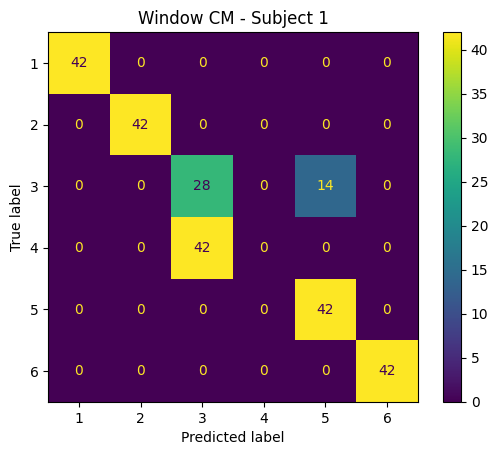


TRIAL ACC: 0.7777777777777778
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.40      0.67      0.50         3
           4       0.00      0.00      0.00         3
           5       0.75      1.00      0.86         3
           6       1.00      1.00      1.00         3

    accuracy                           0.78        18
   macro avg       0.69      0.78      0.73        18
weighted avg       0.69      0.78      0.73        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

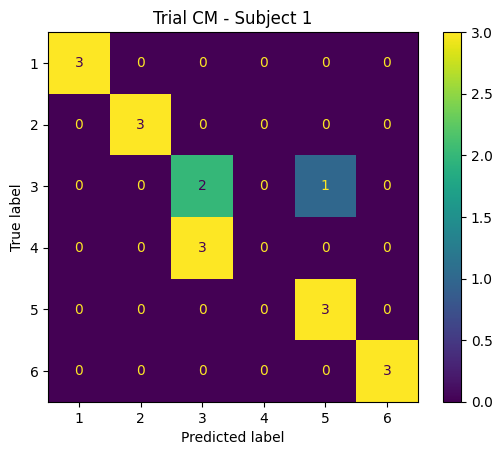


TEST SUBJECT: 2
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_1    │ (None, 200, 24)   │          0 │ input_layer_1[0]… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_6 (Lambda)   │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_7 (Lambda)   │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_8 (Lambda)   │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_9 (Lambda)   │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_8 (Conv1D)   │ (None, 200, 32)   │        992 │ lambda_6[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_10 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_7[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_12 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_8[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_14 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_9[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_8[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_10[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_12[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_14[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_9 (Conv1D)   │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_11 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_13 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_15 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_9[0][0]    │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_11[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_13[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.3905 - loss: 1.7634 - val_accuracy: 0.6161 - val_loss: 1.7002 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6005 - loss: 1.5486 - val_accuracy: 0.7118 - val_loss: 1.2015 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6801 - loss: 1.2356
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7053 - loss: 1.1437 - val_accuracy: 0.7564 - val_loss: 0.8267 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7510 - loss: 0.9409 - val_accuracy: 0.7599 - val_loss: 0.7527 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7581 - loss: 0.8681 - val_accuracy: 0.7718 - val_loss: 0.7103 - learning_rate: 5.0000e-05
Epoch 6/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

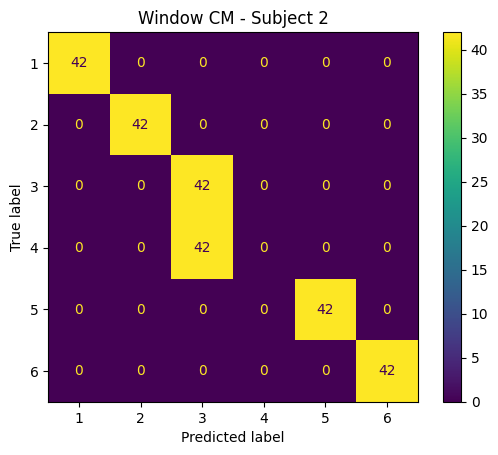


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.50      1.00      0.67         3
           4       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

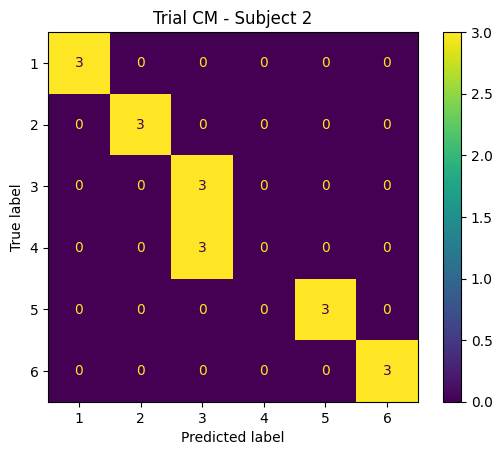


TEST SUBJECT: 3
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_2    │ (None, 200, 24)   │          0 │ input_layer_2[0]… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_12 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_13 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_14 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_15 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_16 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_12[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_18 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_13[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_20 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_14[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_22 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_15[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_16[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_18[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_20[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_22[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_17 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_19 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_21 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_23 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_17[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_19[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_21[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 14s 29ms/step - accuracy: 0.3363 - loss: 1.7533 - val_accuracy: 0.5030 - val_loss: 1.6539 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5242 - loss: 1.4956 - val_accuracy: 0.6822 - val_loss: 1.2457 - learning_rate: 1.0000e-04
Epoch 3/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6584 - loss: 1.2371
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6853 - loss: 1.1604 - val_accuracy: 0.7771 - val_loss: 0.9457 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7340 - loss: 0.9565 - val_accuracy: 0.7746 - val_loss: 0.8655 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7491 - loss: 0.8771 - val_accuracy: 0.7885 - val_loss: 0.8228 - learning_rate: 5.0000e-05
Epoch 6/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

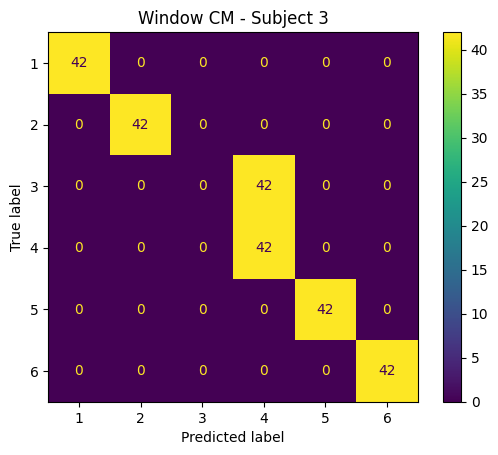


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         3
           4       0.50      1.00      0.67         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

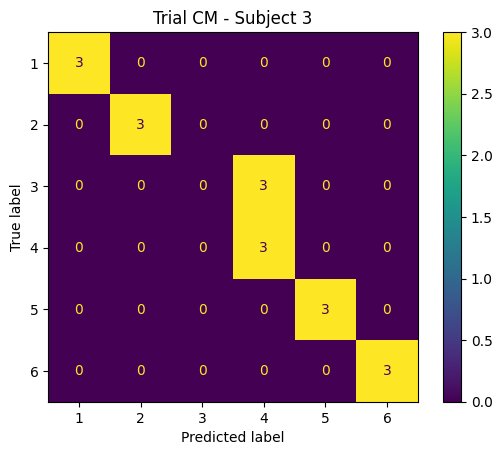


TEST SUBJECT: 4
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_3    │ (None, 200, 24)   │          0 │ input_layer_3[0]… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_18 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_19 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_20 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_21 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_24 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_18[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_26 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_19[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_28 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_20[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_30 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_21[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_24[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_26[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_28[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_30[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_25 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_27 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_29 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_31 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_25[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_27[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_29[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4089 - loss: 1.7654 - val_accuracy: 0.7382 - val_loss: 1.6995 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6523 - loss: 1.5261 - val_accuracy: 0.7481 - val_loss: 1.2046 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6796 - loss: 1.2247
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6961 - loss: 1.1437 - val_accuracy: 0.7551 - val_loss: 0.8737 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7286 - loss: 0.9627 - val_accuracy: 0.8089 - val_loss: 0.7955 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7507 - loss: 0.8965 - val_accuracy: 0.8178 - val_loss: 0.7362 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

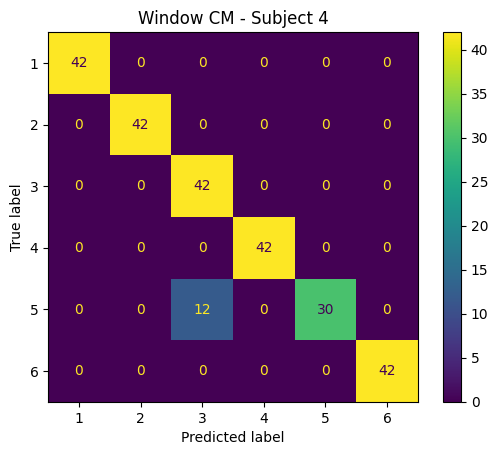


TRIAL ACC: 0.9444444444444444
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.75      1.00      0.86         3
           4       1.00      1.00      1.00         3
           5       1.00      0.67      0.80         3
           6       1.00      1.00      1.00         3

    accuracy                           0.94        18
   macro avg       0.96      0.94      0.94        18
weighted avg       0.96      0.94      0.94        18



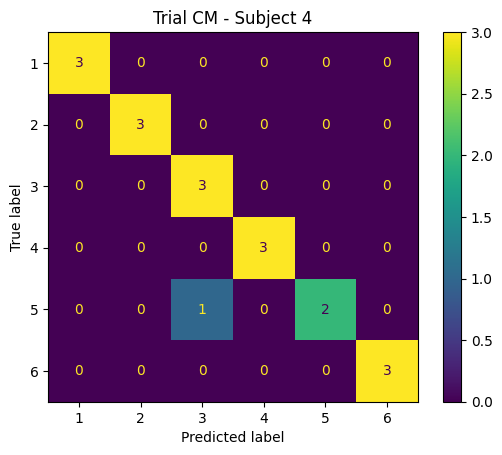


TEST SUBJECT: 5
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_4    │ (None, 200, 24)   │          0 │ input_layer_4[0]… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_24 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_25 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_26 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_27 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_32 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_24[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_34 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_25[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_36 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_26[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_38 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_27[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_32[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_34[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_36[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_38[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_33 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_35 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_37 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_39 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_33[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_35[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_37[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4883 - loss: 1.7520 - val_accuracy: 0.6703 - val_loss: 1.6650 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6970 - loss: 1.4718 - val_accuracy: 0.6832 - val_loss: 1.1486 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7301 - loss: 1.1550
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7399 - loss: 1.0772 - val_accuracy: 0.7309 - val_loss: 0.8444 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7713 - loss: 0.8881 - val_accuracy: 0.7214 - val_loss: 0.7761 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7765 - loss: 0.8312 - val_accuracy: 0.7388 - val_loss: 0.7414 - learning_rate: 5.0000e-05
Epoch 6/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accurac

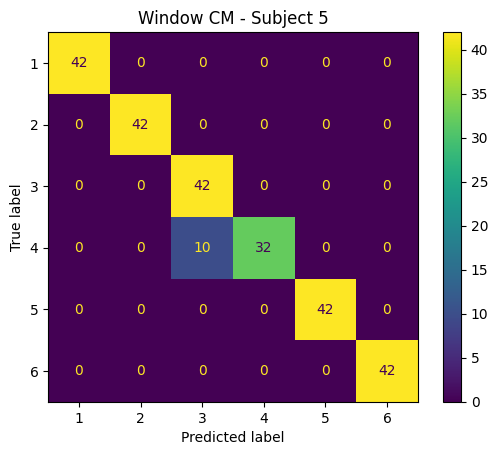


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



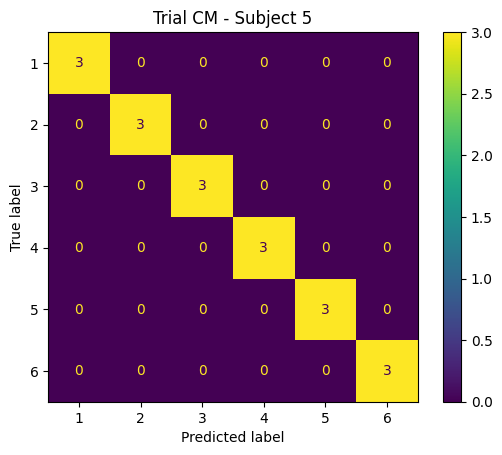


TEST SUBJECT: 6
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_5    │ (None, 200, 24)   │          0 │ input_layer_5[0]… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_30 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_5… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_31 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_5… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_32 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_5… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_33 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_5… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_40 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_30[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_42 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_31[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_44 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_32[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_46 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_33[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_40[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_42[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_44[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_46[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_41 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_43 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_45 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_47 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_41[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_43[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_45[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.4022 - loss: 1.7597 - val_accuracy: 0.6428 - val_loss: 1.6897 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.5959 - loss: 1.5296 - val_accuracy: 0.6378 - val_loss: 1.2354 - learning_rate: 1.0000e-04
Epoch 3/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6913 - loss: 1.2411
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7080 - loss: 1.1577 - val_accuracy: 0.7577 - val_loss: 0.8823 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7478 - loss: 0.9458 - val_accuracy: 0.7537 - val_loss: 0.8041 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7682 - loss: 0.8714 - val_accuracy: 0.7642 - val_loss: 0.7614 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

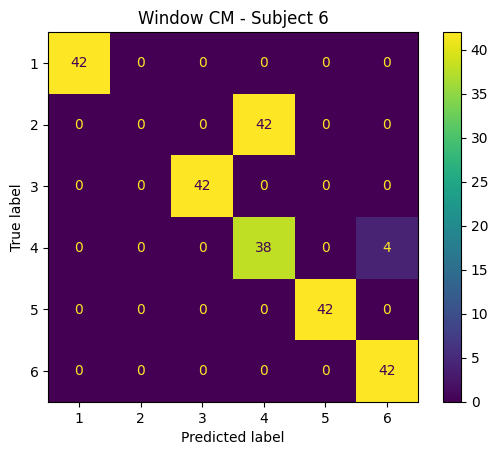


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.00      0.00      0.00         3
           3       1.00      1.00      1.00         3
           4       0.50      1.00      0.67         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

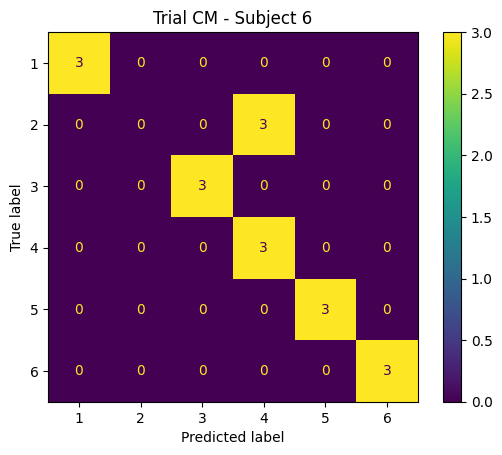


TEST SUBJECT: 7
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_6"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_6       │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_6    │ (None, 200, 24)   │          0 │ input_layer_6[0]… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_36 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_6… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_37 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_6… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_38 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_6… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_39 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_6… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_48 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_36[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_50 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_37[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_52 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_38[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_54 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_39[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_48[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_50[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_52[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_54[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_49 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_51 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_53 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_55 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_49[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_51[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_53[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.4226 - loss: 1.7615 - val_accuracy: 0.6408 - val_loss: 1.6918 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6030 - loss: 1.4983 - val_accuracy: 0.6980 - val_loss: 1.1909 - learning_rate: 1.0000e-04
Epoch 3/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6528 - loss: 1.2017
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6706 - loss: 1.1255 - val_accuracy: 0.8291 - val_loss: 0.8737 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7274 - loss: 0.9374 - val_accuracy: 0.8733 - val_loss: 0.7861 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7588 - loss: 0.8583 - val_accuracy: 0.8693 - val_loss: 0.7295 - learning_rate: 5.0000e-05
Epoch 6/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accurac

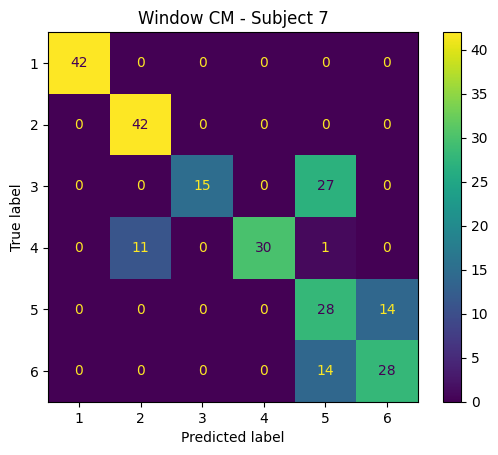


TRIAL ACC: 0.7222222222222222
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.75      1.00      0.86         3
           3       1.00      0.33      0.50         3
           4       1.00      0.67      0.80         3
           5       0.40      0.67      0.50         3
           6       0.67      0.67      0.67         3

    accuracy                           0.72        18
   macro avg       0.80      0.72      0.72        18
weighted avg       0.80      0.72      0.72        18



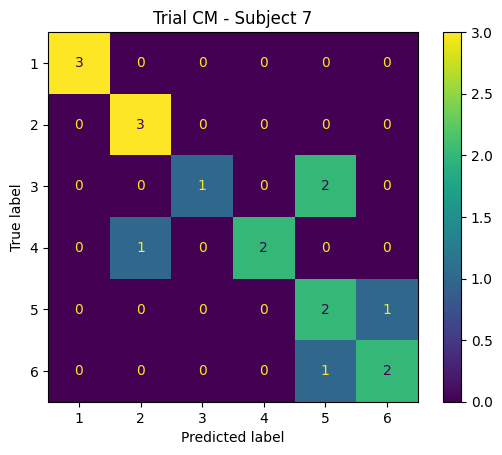


TEST SUBJECT: 8
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_7       │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_7    │ (None, 200, 24)   │          0 │ input_layer_7[0]… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_42 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_7… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_43 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_7… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_44 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_7… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_45 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_7… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_56 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_42[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_58 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_43[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_60 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_44[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_62 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_45[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_56[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_58[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_60[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_62[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_57 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_59 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_61 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_63 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_57[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_59[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_61[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3365 - loss: 1.7534 - val_accuracy: 0.6428 - val_loss: 1.6702 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5243 - loss: 1.5172 - val_accuracy: 0.6761 - val_loss: 1.2277 - learning_rate: 1.0000e-04
Epoch 3/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6083 - loss: 1.2827
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6507 - loss: 1.2067 - val_accuracy: 0.7851 - val_loss: 0.9141 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7209 - loss: 1.0277 - val_accuracy: 0.8259 - val_loss: 0.7874 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7381 - loss: 0.9413 - val_accuracy: 0.8493 - val_loss: 0.7018 - learning_rate: 5.0000e-05
Epoch 6/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accurac

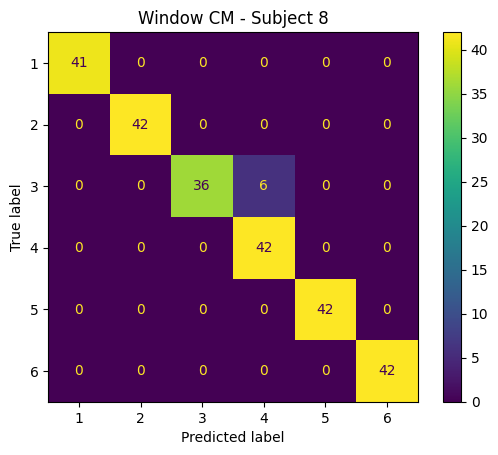


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



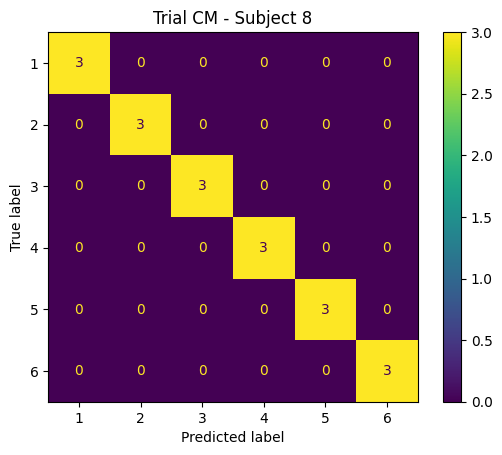


TEST SUBJECT: 9
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_8       │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_8    │ (None, 200, 24)   │          0 │ input_layer_8[0]… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_48 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_8… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_49 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_8… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_50 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_8… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_51 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_8… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_64 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_48[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_66 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_49[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_68 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_50[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_70 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_51[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_64[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_66[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_68[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_70[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_65 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_67 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_69 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_71 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_65[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_67[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_69[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4202 - loss: 1.7583 - val_accuracy: 0.6066 - val_loss: 1.6703 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5977 - loss: 1.5045 - val_accuracy: 0.7615 - val_loss: 1.1625 - learning_rate: 1.0000e-04
Epoch 3/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6922 - loss: 1.2201
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7141 - loss: 1.1456 - val_accuracy: 0.8192 - val_loss: 0.8459 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7582 - loss: 0.9564 - val_accuracy: 0.8157 - val_loss: 0.7382 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7782 - loss: 0.8691 - val_accuracy: 0.8142 - val_loss: 0.6707 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

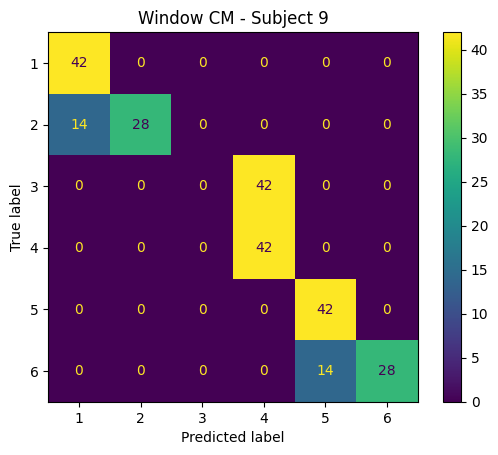


TRIAL ACC: 0.7222222222222222
              precision    recall  f1-score   support

           1       0.75      1.00      0.86         3
           2       1.00      0.67      0.80         3
           3       0.00      0.00      0.00         3
           4       0.50      1.00      0.67         3
           5       0.75      1.00      0.86         3
           6       1.00      0.67      0.80         3

    accuracy                           0.72        18
   macro avg       0.67      0.72      0.66        18
weighted avg       0.67      0.72      0.66        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

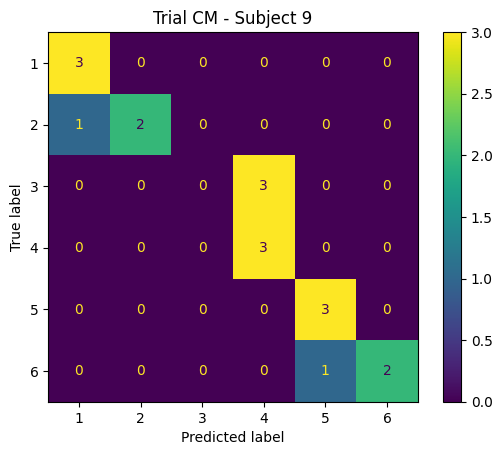


TEST SUBJECT: 10
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_9       │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_9    │ (None, 200, 24)   │          0 │ input_layer_9[0]… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_54 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_9… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_55 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_9… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_56 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_9… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_57 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_9… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_72 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_54[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_74 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_55[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_76 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_56[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_78 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_57[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_72[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_74[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_76[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_78[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_73 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_75 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_77 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_79 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_73[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_75[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_77[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3815 - loss: 1.7587 - val_accuracy: 0.6539 - val_loss: 1.6930 - learning_rate: 1.0000e-04
Epoch 2/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5583 - loss: 1.5449 - val_accuracy: 0.7326 - val_loss: 1.2996 - learning_rate: 1.0000e-04
Epoch 3/60
259/260 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6784 - loss: 1.2831
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6935 - loss: 1.2047 - val_accuracy: 0.7410 - val_loss: 0.9359 - learning_rate: 1.0000e-04
Epoch 4/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7498 - loss: 0.9766 - val_accuracy: 0.7620 - val_loss: 0.8240 - learning_rate: 5.0000e-05
Epoch 5/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7588 - loss: 0.8817 - val_accuracy: 0.7699 - val_loss: 0.7569 - learning_rate: 5.0000e-05
Epoch 6/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accurac

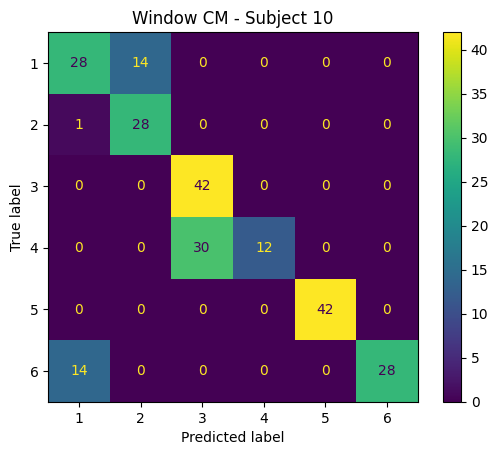


TRIAL ACC: 0.7222222222222222
              precision    recall  f1-score   support

           1       0.50      0.67      0.57         3
           2       0.67      0.67      0.67         3
           3       0.60      1.00      0.75         3
           4       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         3
           6       1.00      0.67      0.80         3

    accuracy                           0.72        18
   macro avg       0.79      0.72      0.71        18
weighted avg       0.79      0.72      0.71        18



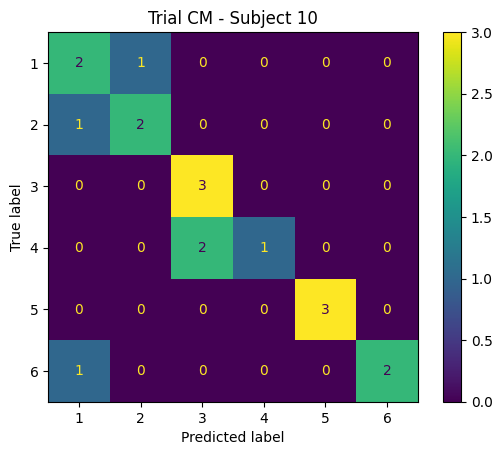


TEST SUBJECT: 11
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_10      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_10   │ (None, 200, 24)   │          0 │ input_layer_10[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_60 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_61 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_62 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_63 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_80 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_60[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_82 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_61[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_84 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_62[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_86 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_63[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_80[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_82[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_84[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_86[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_81 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_83 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_85 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_87 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_81[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_83[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_85[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.4139 - loss: 1.7643 - val_accuracy: 0.7470 - val_loss: 1.7089 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6601 - loss: 1.5431 - val_accuracy: 0.8653 - val_loss: 1.1917 - learning_rate: 1.0000e-04
Epoch 3/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7135 - loss: 1.2329
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7315 - loss: 1.1396 - val_accuracy: 0.8499 - val_loss: 0.8081 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7681 - loss: 0.9210 - val_accuracy: 0.8514 - val_loss: 0.7243 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7751 - loss: 0.8458 - val_accuracy: 0.8583 - val_loss: 0.6809 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

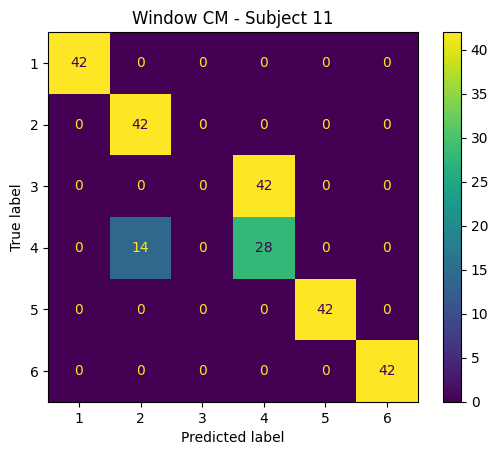


TRIAL ACC: 0.7777777777777778
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.75      1.00      0.86         3
           3       0.00      0.00      0.00         3
           4       0.40      0.67      0.50         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.78        18
   macro avg       0.69      0.78      0.73        18
weighted avg       0.69      0.78      0.73        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

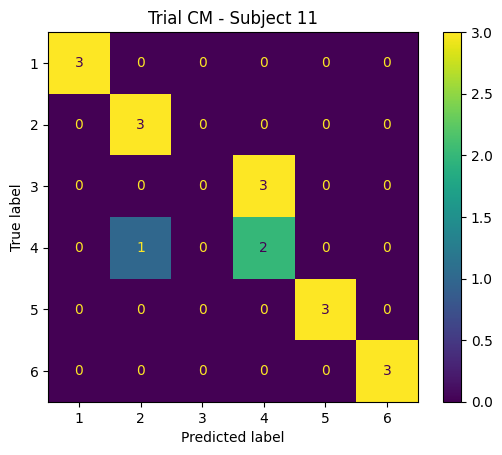


TEST SUBJECT: 12
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_11"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_11      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_11   │ (None, 200, 24)   │          0 │ input_layer_11[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_66 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_67 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_68 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_69 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_88 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_66[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_90 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_67[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_92 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_68[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_94 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_69[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_88[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_90[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_92[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_94[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_89 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_91 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_93 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_95 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_89[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_91[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_93[0][0] 

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 11s 25ms/step - accuracy: 0.4209 - loss: 1.7570 - val_accuracy: 0.5999 - val_loss: 1.6714 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.5824 - loss: 1.5019 - val_accuracy: 0.6128 - val_loss: 1.2443 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6252 - loss: 1.2574
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.6519 - loss: 1.1938 - val_accuracy: 0.7406 - val_loss: 0.9823 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7242 - loss: 1.0178 - val_accuracy: 0.7684 - val_loss: 0.8953 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7577 - loss: 0.9313 - val_accuracy: 0.7619 - val_loss: 0.8371 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accurac

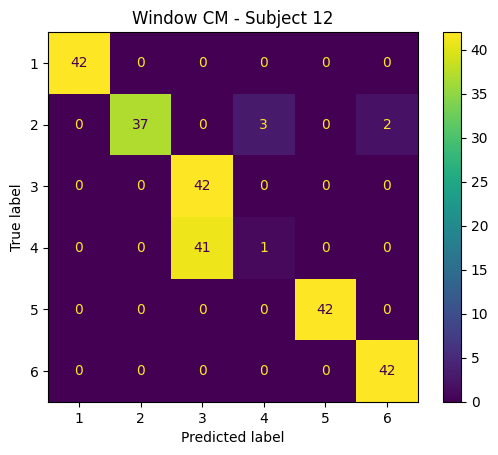


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.50      1.00      0.67         3
           4       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

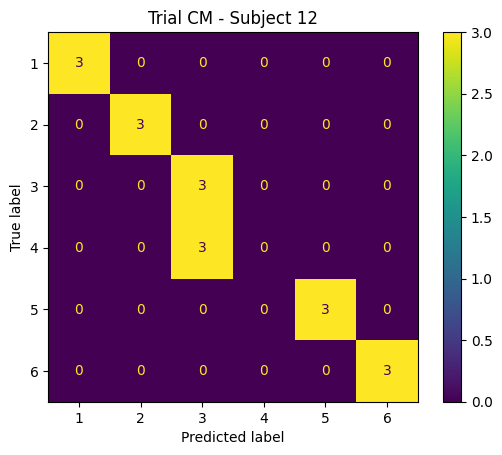


TEST SUBJECT: 13
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_12"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_12      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_12   │ (None, 200, 24)   │          0 │ input_layer_12[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_72 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_73 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_74 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_75 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_96 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_72[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_98 (Conv1D)  │ (None, 200, 32)   │        992 │ lambda_73[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_100 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_74[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_102 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_75[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_96[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_98[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_100[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_102[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_97 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_99 (Conv1D)  │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_101 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_103 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_97[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_99[0][0]   │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_101[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 25ms/step - accuracy: 0.4042 - loss: 1.7623 - val_accuracy: 0.6958 - val_loss: 1.6843 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6244 - loss: 1.5200 - val_accuracy: 0.6983 - val_loss: 1.1710 - learning_rate: 1.0000e-04
Epoch 3/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6921 - loss: 1.2177
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7063 - loss: 1.1393 - val_accuracy: 0.7901 - val_loss: 0.9321 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7456 - loss: 0.9457 - val_accuracy: 0.7985 - val_loss: 0.8771 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7595 - loss: 0.8710 - val_accuracy: 0.7960 - val_loss: 0.8413 - learning_rate: 5.0000e-05
Epoch 6/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accurac

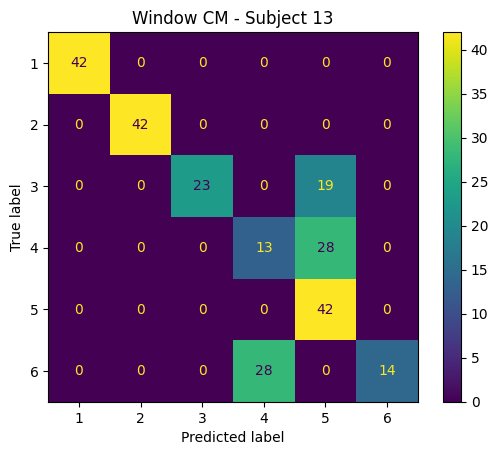


TRIAL ACC: 0.7222222222222222
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       0.33      0.33      0.33         3
           5       0.50      1.00      0.67         3
           6       1.00      0.33      0.50         3

    accuracy                           0.72        18
   macro avg       0.81      0.72      0.72        18
weighted avg       0.81      0.72      0.72        18



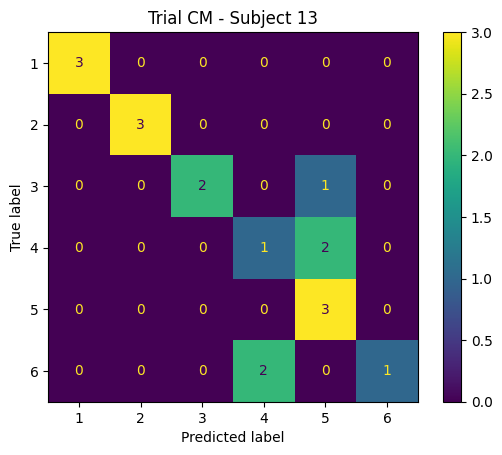


TEST SUBJECT: 14
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_13"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_13      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_13   │ (None, 200, 24)   │          0 │ input_layer_13[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_78 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_79 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_80 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_81 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_104 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_78[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_106 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_79[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_108 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_80[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_110 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_81[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_104[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_106[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_108[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_110[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_105 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_107 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_109 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_111 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_105[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_107[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_109[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 13s 28ms/step - accuracy: 0.4392 - loss: 1.7528 - val_accuracy: 0.6510 - val_loss: 1.6711 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.6151 - loss: 1.4832 - val_accuracy: 0.7109 - val_loss: 1.1745 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6876 - loss: 1.1886
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7003 - loss: 1.1122 - val_accuracy: 0.7881 - val_loss: 0.8494 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7286 - loss: 0.9355 - val_accuracy: 0.7827 - val_loss: 0.7713 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7438 - loss: 0.8714 - val_accuracy: 0.7802 - val_loss: 0.7289 - learning_rate: 5.0000e-05
Epoch 6/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

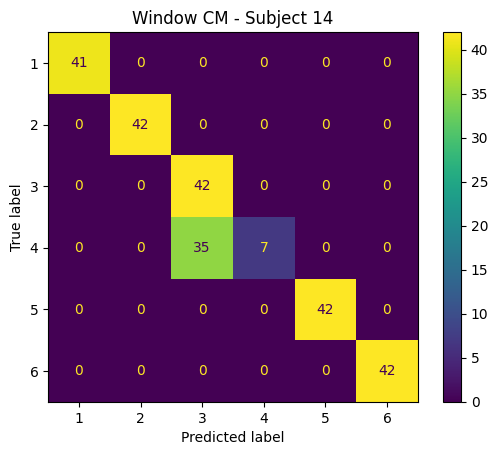


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.60      1.00      0.75         3
           4       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.89        18
   macro avg       0.93      0.89      0.88        18
weighted avg       0.93      0.89      0.88        18



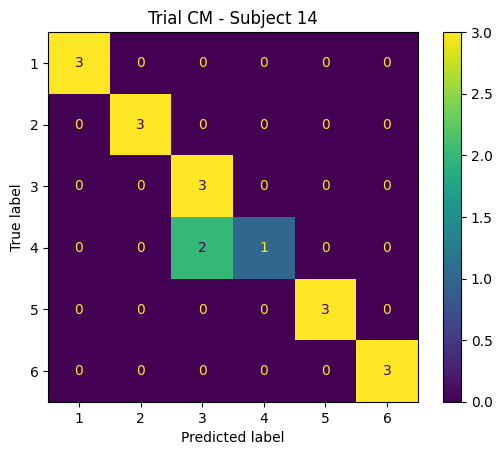


TEST SUBJECT: 15
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_14"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_14      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_14   │ (None, 200, 24)   │          0 │ input_layer_14[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_84 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_85 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_86 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_87 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_112 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_84[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_114 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_85[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_116 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_86[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_118 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_87[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_112[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_114[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_116[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_118[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_113 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_115 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_117 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_119 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_113[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_115[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_117[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4134 - loss: 1.7553 - val_accuracy: 0.6817 - val_loss: 1.6748 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6283 - loss: 1.4976 - val_accuracy: 0.6852 - val_loss: 1.1679 - learning_rate: 1.0000e-04
Epoch 3/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7153 - loss: 1.1934
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7302 - loss: 1.1120 - val_accuracy: 0.7249 - val_loss: 0.8664 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7631 - loss: 0.9138 - val_accuracy: 0.7329 - val_loss: 0.8032 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7769 - loss: 0.8403 - val_accuracy: 0.7393 - val_loss: 0.7674 - learning_rate: 5.0000e-05
Epoch 6/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

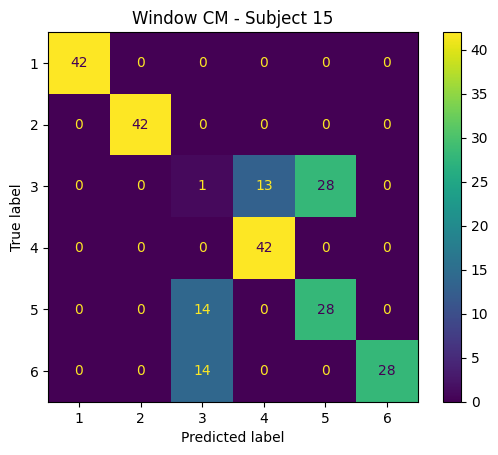


TRIAL ACC: 0.7222222222222222
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         3
           4       0.75      1.00      0.86         3
           5       0.50      0.67      0.57         3
           6       1.00      0.67      0.80         3

    accuracy                           0.72        18
   macro avg       0.71      0.72      0.70        18
weighted avg       0.71      0.72      0.70        18



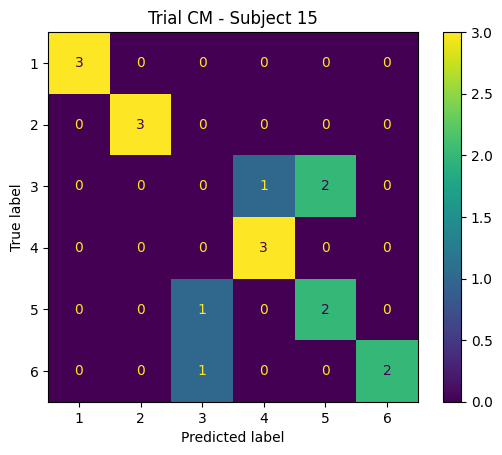


TEST SUBJECT: 17
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_15"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_15      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_15   │ (None, 200, 24)   │          0 │ input_layer_15[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_90 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_91 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_92 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_93 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_120 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_90[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_122 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_91[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_124 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_92[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_126 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_93[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_120[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_122[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_124[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_126[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_121 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_123 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_125 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_127 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_121[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_123[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_125[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4086 - loss: 1.7531 - val_accuracy: 0.6449 - val_loss: 1.6579 - learning_rate: 1.0000e-04
Epoch 2/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5858 - loss: 1.5129 - val_accuracy: 0.7877 - val_loss: 1.1792 - learning_rate: 1.0000e-04
Epoch 3/60
259/260 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6863 - loss: 1.2383
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6982 - loss: 1.1647 - val_accuracy: 0.8756 - val_loss: 0.7860 - learning_rate: 1.0000e-04
Epoch 4/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7334 - loss: 0.9612 - val_accuracy: 0.8646 - val_loss: 0.6854 - learning_rate: 5.0000e-05
Epoch 5/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7453 - loss: 0.8877 - val_accuracy: 0.8462 - val_loss: 0.6316 - learning_rate: 5.0000e-05
Epoch 6/60
258/260 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accurac

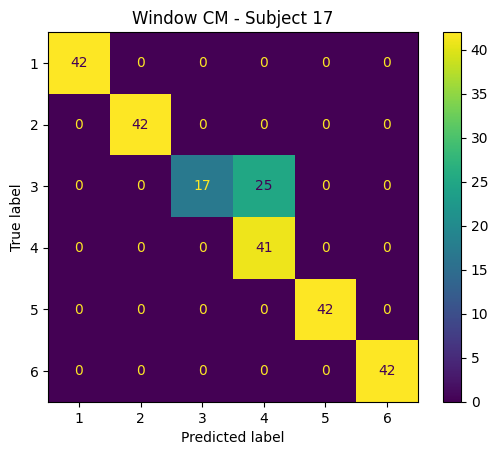


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.33      0.50         3
           4       0.60      1.00      0.75         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.89        18
   macro avg       0.93      0.89      0.88        18
weighted avg       0.93      0.89      0.88        18



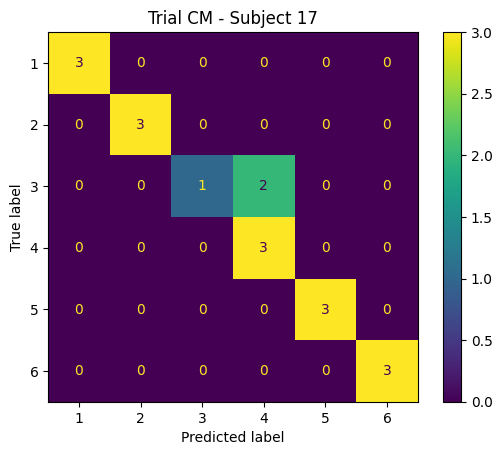


TEST SUBJECT: 18
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_16"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_16      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_16   │ (None, 200, 24)   │          0 │ input_layer_16[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_96 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_97 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_98 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_99 (Lambda)  │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_128 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_96[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_130 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_97[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_132 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_98[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_134 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_99[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_128[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_130[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_132[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_134[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_129 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_131 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_133 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_135 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_129[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_131[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_133[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4223 - loss: 1.7615 - val_accuracy: 0.6675 - val_loss: 1.6811 - learning_rate: 1.0000e-04
Epoch 2/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6138 - loss: 1.5186 - val_accuracy: 0.6540 - val_loss: 1.1703 - learning_rate: 1.0000e-04
Epoch 3/60
259/260 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6592 - loss: 1.2263
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6764 - loss: 1.1545 - val_accuracy: 0.7430 - val_loss: 0.9180 - learning_rate: 1.0000e-04
Epoch 4/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7158 - loss: 0.9807 - val_accuracy: 0.7550 - val_loss: 0.8660 - learning_rate: 5.0000e-05
Epoch 5/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7406 - loss: 0.8985 - val_accuracy: 0.7730 - val_loss: 0.8343 - learning_rate: 5.0000e-05
Epoch 6/60
258/260 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

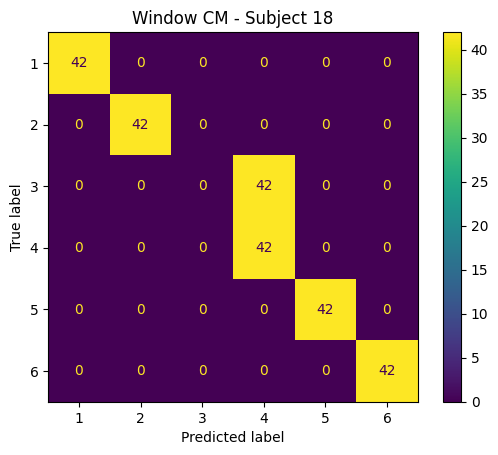


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         3
           4       0.50      1.00      0.67         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

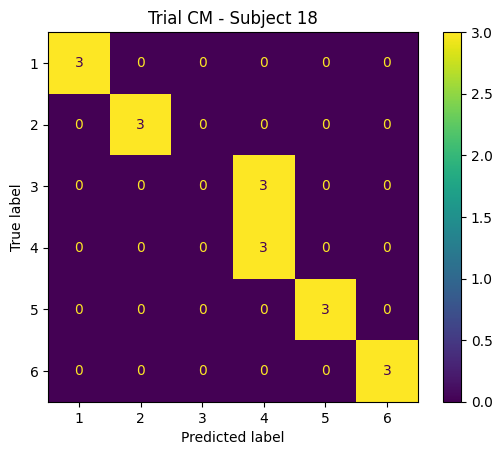


TEST SUBJECT: 19
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_17"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_17      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_17   │ (None, 200, 24)   │          0 │ input_layer_17[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_102 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_103 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_104 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_105 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_136 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_102[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_138 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_103[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_140 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_104[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_142 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_105[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_136[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_138[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_140[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_142[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_137 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_139 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_141 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_143 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_137[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_139[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_141[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4318 - loss: 1.7560 - val_accuracy: 0.7208 - val_loss: 1.6848 - learning_rate: 1.0000e-04
Epoch 2/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6955 - loss: 1.4817 - val_accuracy: 0.7667 - val_loss: 1.1463 - learning_rate: 1.0000e-04
Epoch 3/60
258/260 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7499 - loss: 1.1297
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7485 - loss: 1.0453 - val_accuracy: 0.7917 - val_loss: 0.8282 - learning_rate: 1.0000e-04
Epoch 4/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7710 - loss: 0.8572 - val_accuracy: 0.7957 - val_loss: 0.7800 - learning_rate: 5.0000e-05
Epoch 5/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7724 - loss: 0.8088 - val_accuracy: 0.7977 - val_loss: 0.7599 - learning_rate: 5.0000e-05
Epoch 6/60
259/260 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

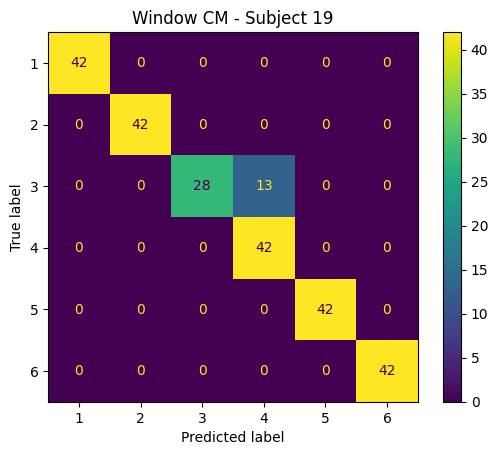


TRIAL ACC: 0.9444444444444444
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.94        18
   macro avg       0.96      0.94      0.94        18
weighted avg       0.96      0.94      0.94        18



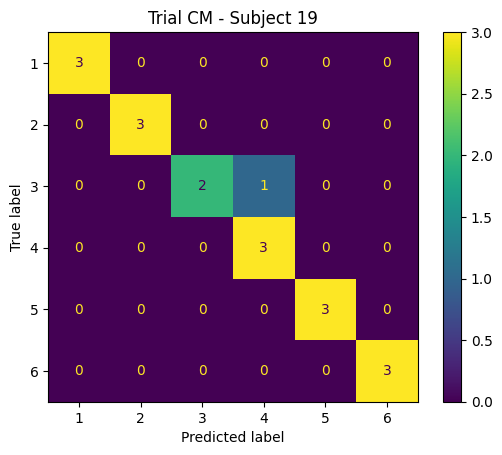


TEST SUBJECT: 20
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_18"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_18      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_18   │ (None, 200, 24)   │          0 │ input_layer_18[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_108 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_109 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_110 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_111 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_144 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_108[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_146 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_109[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_148 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_110[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_150 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_111[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_144[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_146[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_148[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_150[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_145 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_147 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_149 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_151 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_145[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_147[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_149[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4446 - loss: 1.7548 - val_accuracy: 0.6451 - val_loss: 1.6827 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6282 - loss: 1.4884 - val_accuracy: 0.6944 - val_loss: 1.1206 - learning_rate: 1.0000e-04
Epoch 3/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6660 - loss: 1.1727
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6929 - loss: 1.0911 - val_accuracy: 0.7551 - val_loss: 0.8129 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7345 - loss: 0.9305 - val_accuracy: 0.7601 - val_loss: 0.7405 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7648 - loss: 0.8631 - val_accuracy: 0.7770 - val_loss: 0.6918 - learning_rate: 5.0000e-05
Epoch 6/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

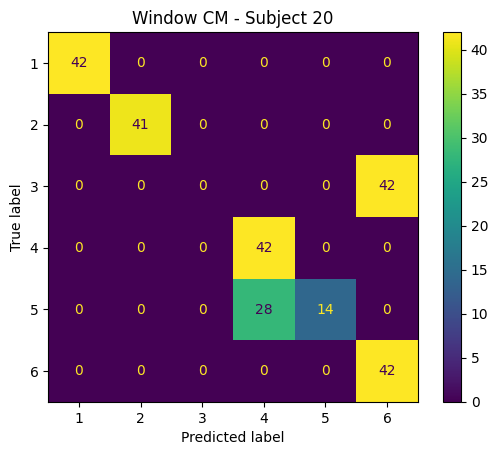


TRIAL ACC: 0.7222222222222222
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         3
           4       0.60      1.00      0.75         3
           5       1.00      0.33      0.50         3
           6       0.50      1.00      0.67         3

    accuracy                           0.72        18
   macro avg       0.68      0.72      0.65        18
weighted avg       0.68      0.72      0.65        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

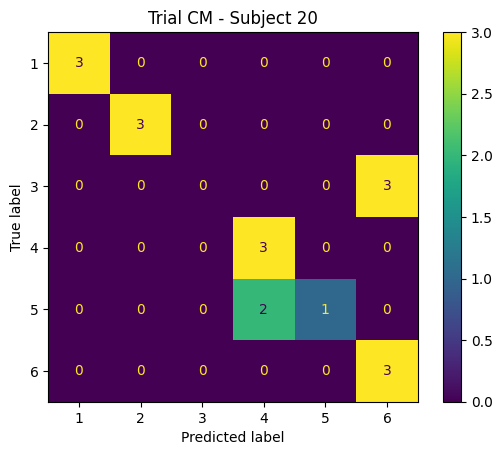


TEST SUBJECT: 22
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_19"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_19      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_19   │ (None, 200, 24)   │          0 │ input_layer_19[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_114 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_115 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_116 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_117 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_1… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_152 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_114[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_154 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_115[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_156 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_116[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_158 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_117[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_152[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_154[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_156[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_158[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_153 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_155 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_157 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_159 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_153[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_155[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_157[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4554 - loss: 1.7535 - val_accuracy: 0.7004 - val_loss: 1.6769 - learning_rate: 1.0000e-04
Epoch 2/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6547 - loss: 1.4935 - val_accuracy: 0.7439 - val_loss: 1.2364 - learning_rate: 1.0000e-04
Epoch 3/60
259/260 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7120 - loss: 1.1987
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
260/260 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7239 - loss: 1.1089 - val_accuracy: 0.7738 - val_loss: 0.9062 - learning_rate: 1.0000e-04
Epoch 4/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7526 - loss: 0.9102 - val_accuracy: 0.8043 - val_loss: 0.8558 - learning_rate: 5.0000e-05
Epoch 5/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7644 - loss: 0.8464 - val_accuracy: 0.8128 - val_loss: 0.8130 - learning_rate: 5.0000e-05
Epoch 6/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

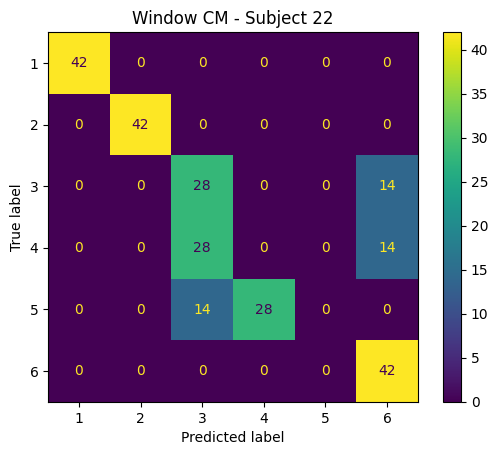


TRIAL ACC: 0.6111111111111112
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.40      0.67      0.50         3
           4       0.00      0.00      0.00         3
           5       0.00      0.00      0.00         3
           6       0.60      1.00      0.75         3

    accuracy                           0.61        18
   macro avg       0.50      0.61      0.54        18
weighted avg       0.50      0.61      0.54        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

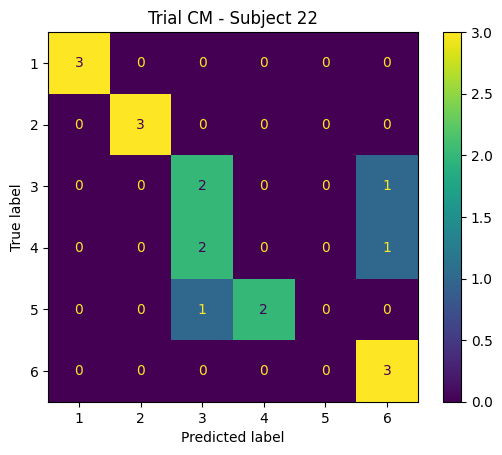


TEST SUBJECT: 23
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_20"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_20      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_20   │ (None, 200, 24)   │          0 │ input_layer_20[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_120 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_121 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_122 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_123 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_160 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_120[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_162 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_121[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_164 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_122[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_166 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_123[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_160[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_162[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_164[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_166[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_161 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_163 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_165 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_167 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_161[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_163[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_165[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.4348 - loss: 1.7501 - val_accuracy: 0.6204 - val_loss: 1.6593 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6006 - loss: 1.4660 - val_accuracy: 0.7214 - val_loss: 1.0784 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6693 - loss: 1.1740
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6841 - loss: 1.1175 - val_accuracy: 0.8159 - val_loss: 0.8085 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7287 - loss: 0.9628 - val_accuracy: 0.8249 - val_loss: 0.7328 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7397 - loss: 0.9041 - val_accuracy: 0.8358 - val_loss: 0.6797 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

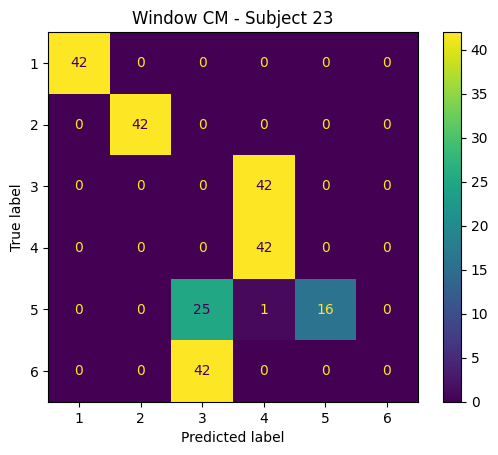


TRIAL ACC: 0.5555555555555556
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         3
           4       0.50      1.00      0.67         3
           5       1.00      0.33      0.50         3
           6       0.00      0.00      0.00         3

    accuracy                           0.56        18
   macro avg       0.58      0.56      0.53        18
weighted avg       0.58      0.56      0.53        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

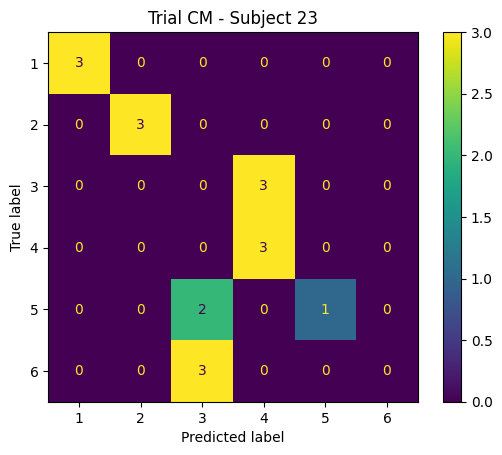


TEST SUBJECT: 24
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_21"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_21      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_21   │ (None, 200, 24)   │          0 │ input_layer_21[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_126 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_127 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_128 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_129 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_168 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_126[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_170 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_127[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_172 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_128[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_174 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_129[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_168[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_170[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_172[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_174[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_169 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_171 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_173 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_175 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_169[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_171[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_173[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4269 - loss: 1.7481 - val_accuracy: 0.7285 - val_loss: 1.6602 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6024 - loss: 1.4648 - val_accuracy: 0.7090 - val_loss: 1.1723 - learning_rate: 1.0000e-04
Epoch 3/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6609 - loss: 1.1879
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6812 - loss: 1.1208 - val_accuracy: 0.7962 - val_loss: 0.9052 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7325 - loss: 0.9465 - val_accuracy: 0.7947 - val_loss: 0.8223 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7444 - loss: 0.8762 - val_accuracy: 0.8132 - val_loss: 0.7704 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

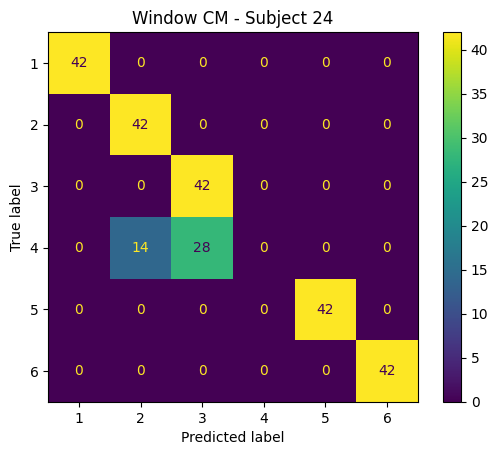


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.75      1.00      0.86         3
           3       0.60      1.00      0.75         3
           4       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.72      0.83      0.77        18
weighted avg       0.73      0.83      0.77        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

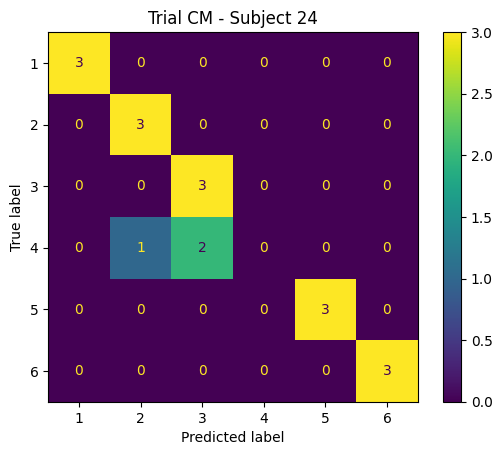


TEST SUBJECT: 25
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_22"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_22      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_22   │ (None, 200, 24)   │          0 │ input_layer_22[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_132 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_133 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_134 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_135 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_176 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_132[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_178 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_133[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_180 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_134[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_182 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_135[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_176[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_178[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_180[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_182[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_177 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_179 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_181 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_183 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_177[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_179[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_181[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3923 - loss: 1.7620 - val_accuracy: 0.5852 - val_loss: 1.7021 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5711 - loss: 1.5080 - val_accuracy: 0.7343 - val_loss: 1.1948 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6554 - loss: 1.2185
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6904 - loss: 1.1370 - val_accuracy: 0.8051 - val_loss: 0.8641 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7570 - loss: 0.9463 - val_accuracy: 0.8185 - val_loss: 0.7694 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7769 - loss: 0.8622 - val_accuracy: 0.8081 - val_loss: 0.7145 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

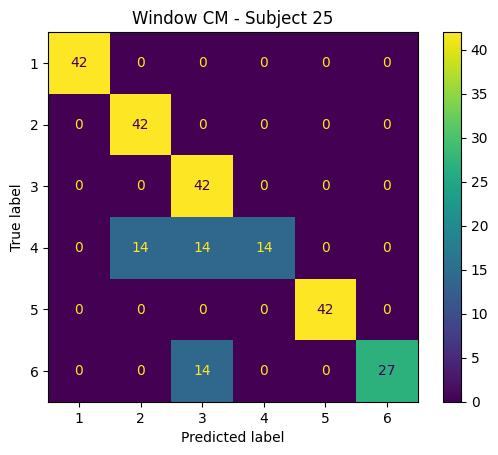


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.75      1.00      0.86         3
           3       0.60      1.00      0.75         3
           4       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         3
           6       1.00      0.67      0.80         3

    accuracy                           0.83        18
   macro avg       0.89      0.83      0.82        18
weighted avg       0.89      0.83      0.82        18



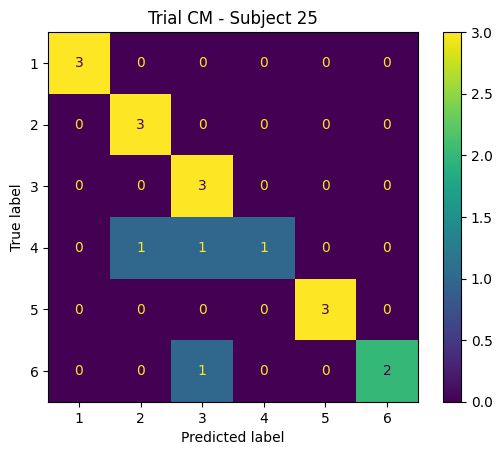


TEST SUBJECT: 27
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_23      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_23   │ (None, 200, 24)   │          0 │ input_layer_23[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_138 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_139 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_140 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_141 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_184 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_138[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_186 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_139[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_188 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_140[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_190 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_141[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_184[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_186[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_188[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_190[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_185 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_187 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_189 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_191 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_185[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_187[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_189[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3937 - loss: 1.7402 - val_accuracy: 0.6452 - val_loss: 1.6399 - learning_rate: 1.0000e-04
Epoch 2/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5898 - loss: 1.4675 - val_accuracy: 0.6887 - val_loss: 1.2155 - learning_rate: 1.0000e-04
Epoch 3/60
259/260 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6932 - loss: 1.1953
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7085 - loss: 1.1236 - val_accuracy: 0.7401 - val_loss: 0.9406 - learning_rate: 1.0000e-04
Epoch 4/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7542 - loss: 0.9247 - val_accuracy: 0.7436 - val_loss: 0.8760 - learning_rate: 5.0000e-05
Epoch 5/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7731 - loss: 0.8468 - val_accuracy: 0.7561 - val_loss: 0.8437 - learning_rate: 5.0000e-05
Epoch 6/60
258/260 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

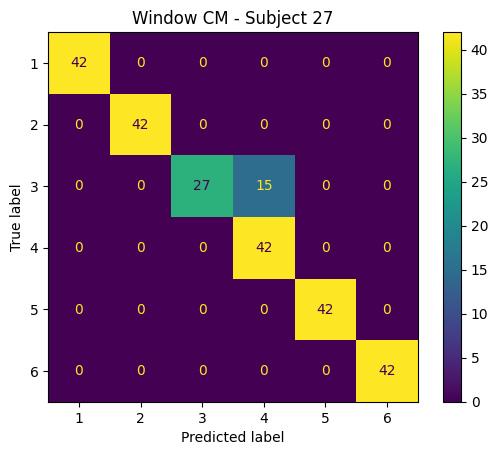


TRIAL ACC: 0.9444444444444444
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       0.75      1.00      0.86         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.94        18
   macro avg       0.96      0.94      0.94        18
weighted avg       0.96      0.94      0.94        18



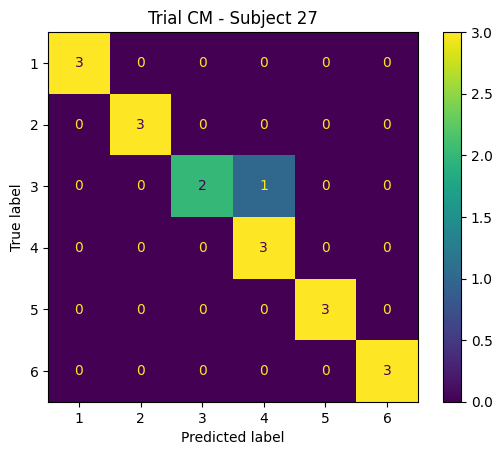


TEST SUBJECT: 28
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_24"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_24      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_24   │ (None, 200, 24)   │          0 │ input_layer_24[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_144 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_145 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_146 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_147 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_192 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_144[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_194 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_145[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_196 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_146[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_198 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_147[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_192[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_194[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_196[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_198[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_193 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_195 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_197 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_199 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_193[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_195[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_197[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.4333 - loss: 1.7542 - val_accuracy: 0.6331 - val_loss: 1.6658 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6341 - loss: 1.4807 - val_accuracy: 0.7542 - val_loss: 1.1512 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7126 - loss: 1.1771
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7210 - loss: 1.0967 - val_accuracy: 0.8156 - val_loss: 0.8082 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7411 - loss: 0.9158 - val_accuracy: 0.8275 - val_loss: 0.7282 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7581 - loss: 0.8454 - val_accuracy: 0.8330 - val_loss: 0.6852 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

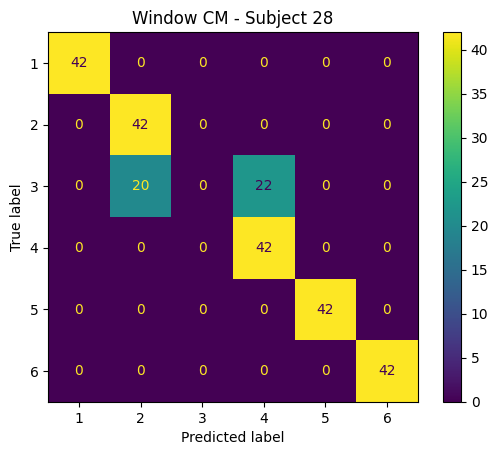


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.75      1.00      0.86         3
           3       0.00      0.00      0.00         3
           4       0.60      1.00      0.75         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.72      0.83      0.77        18
weighted avg       0.73      0.83      0.77        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

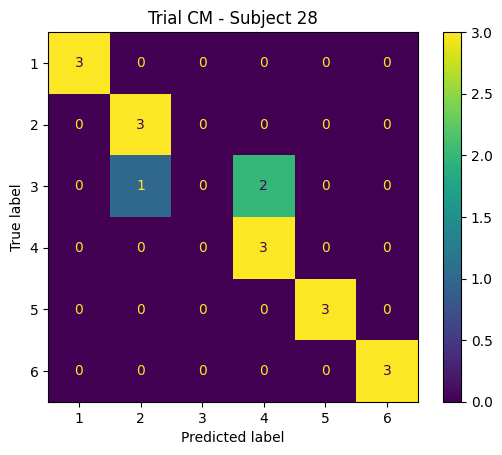


TEST SUBJECT: 30
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_25"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_25      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_25   │ (None, 200, 24)   │          0 │ input_layer_25[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_150 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_151 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_152 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_153 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_200 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_150[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_202 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_151[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_204 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_152[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_206 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_153[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_200[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_202[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_204[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_206[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_201 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_203 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_205 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_207 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_201[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_203[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_205[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.3997 - loss: 1.7627 - val_accuracy: 0.6268 - val_loss: 1.7094 - learning_rate: 1.0000e-04
Epoch 2/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6615 - loss: 1.5137 - val_accuracy: 0.6453 - val_loss: 1.2364 - learning_rate: 1.0000e-04
Epoch 3/60
259/260 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7285 - loss: 1.1805
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7316 - loss: 1.0988 - val_accuracy: 0.7064 - val_loss: 0.9612 - learning_rate: 1.0000e-04
Epoch 4/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7609 - loss: 0.8940 - val_accuracy: 0.6938 - val_loss: 0.9016 - learning_rate: 5.0000e-05
Epoch 5/60
260/260 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7774 - loss: 0.8156 - val_accuracy: 0.7179 - val_loss: 0.8752 - learning_rate: 5.0000e-05
Epoch 6/60
258/260 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

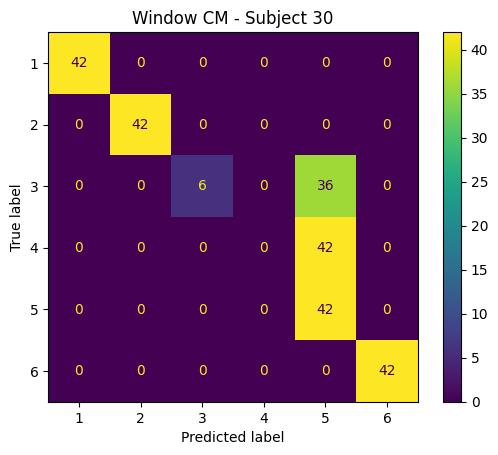


TRIAL ACC: 0.7222222222222222
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.33      0.50         3
           4       0.00      0.00      0.00         3
           5       0.38      1.00      0.55         3
           6       1.00      1.00      1.00         3

    accuracy                           0.72        18
   macro avg       0.73      0.72      0.67        18
weighted avg       0.73      0.72      0.67        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

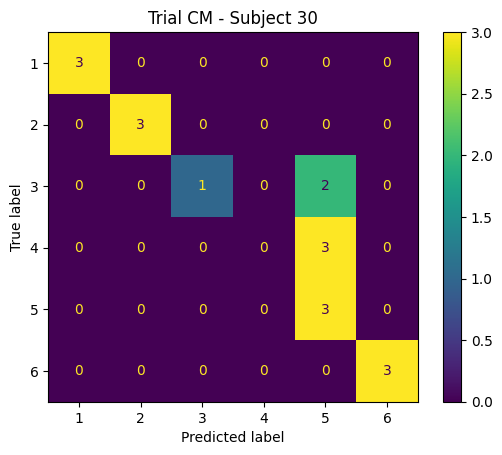


TEST SUBJECT: 31
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_26"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_26      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_26   │ (None, 200, 24)   │          0 │ input_layer_26[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_156 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_157 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_158 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_159 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_208 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_156[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_210 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_157[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_212 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_158[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_214 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_159[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_208[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_210[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_212[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_214[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_209 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_211 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_213 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_215 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_209[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_211[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_213[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.4243 - loss: 1.7645 - val_accuracy: 0.6369 - val_loss: 1.6954 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6135 - loss: 1.5218 - val_accuracy: 0.6503 - val_loss: 1.1578 - learning_rate: 1.0000e-04
Epoch 3/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6419 - loss: 1.2234
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6596 - loss: 1.1461 - val_accuracy: 0.7471 - val_loss: 0.8627 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.7231 - loss: 0.9755 - val_accuracy: 0.7874 - val_loss: 0.7837 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7505 - loss: 0.9098 - val_accuracy: 0.8132 - val_loss: 0.7331 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accurac

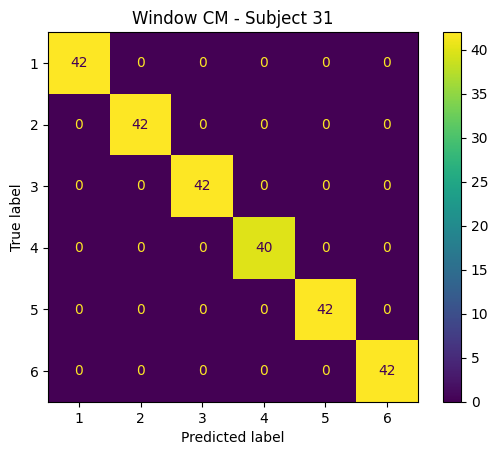


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



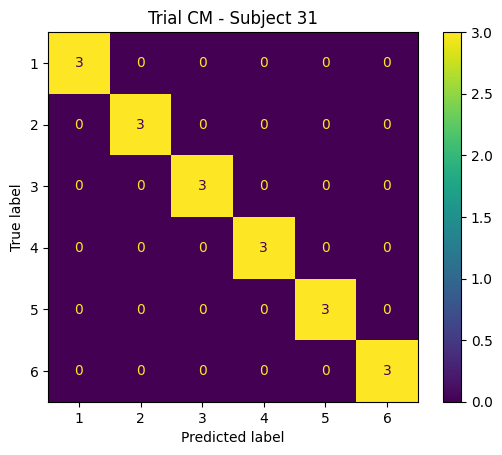


TEST SUBJECT: 32
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_27"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_27      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_27   │ (None, 200, 24)   │          0 │ input_layer_27[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_162 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_163 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_164 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_165 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_216 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_162[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_218 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_163[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_220 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_164[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_222 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_165[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_216[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_218[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_220[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_222[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_217 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_219 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_221 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_223 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_217[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_219[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_221[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.3940 - loss: 1.7587 - val_accuracy: 0.6354 - val_loss: 1.6738 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6138 - loss: 1.4810 - val_accuracy: 0.6811 - val_loss: 1.1681 - learning_rate: 1.0000e-04
Epoch 3/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6773 - loss: 1.1816
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7002 - loss: 1.1068 - val_accuracy: 0.8117 - val_loss: 0.9152 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7473 - loss: 0.9275 - val_accuracy: 0.8162 - val_loss: 0.8594 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7669 - loss: 0.8558 - val_accuracy: 0.8241 - val_loss: 0.8184 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

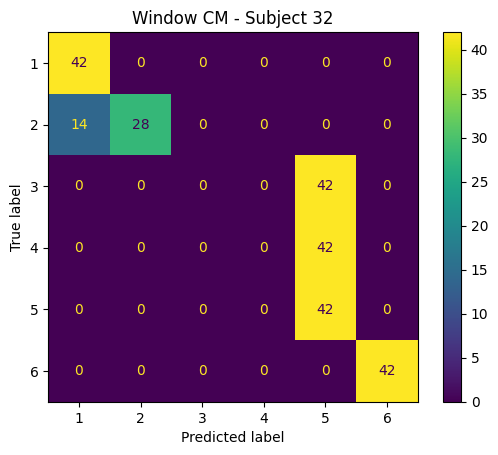


TRIAL ACC: 0.6111111111111112
              precision    recall  f1-score   support

           1       0.75      1.00      0.86         3
           2       1.00      0.67      0.80         3
           3       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         3
           5       0.33      1.00      0.50         3
           6       1.00      1.00      1.00         3

    accuracy                           0.61        18
   macro avg       0.51      0.61      0.53        18
weighted avg       0.51      0.61      0.53        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

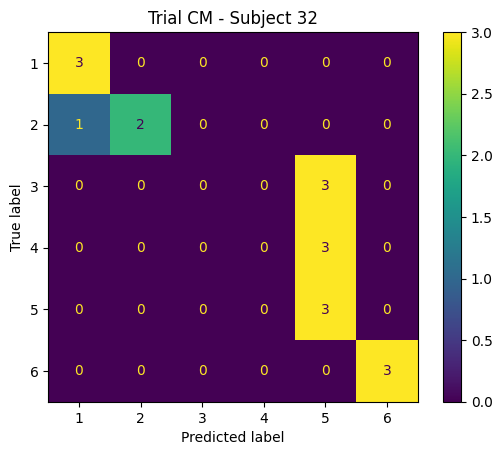


TEST SUBJECT: 33
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_28"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_28      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_28   │ (None, 200, 24)   │          0 │ input_layer_28[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_168 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_169 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_170 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_171 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_224 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_168[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_226 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_169[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_228 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_170[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_230 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_171[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_224[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_226[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_228[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_230[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_225 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_227 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_229 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_231 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_225[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_227[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_229[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - accuracy: 0.4057 - loss: 1.7680 - val_accuracy: 0.6834 - val_loss: 1.7171 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6682 - loss: 1.5465 - val_accuracy: 0.7922 - val_loss: 1.2083 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7171 - loss: 1.2114
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7240 - loss: 1.1256 - val_accuracy: 0.8057 - val_loss: 0.8176 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7652 - loss: 0.9202 - val_accuracy: 0.8166 - val_loss: 0.7279 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7805 - loss: 0.8508 - val_accuracy: 0.8424 - val_loss: 0.6738 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accurac

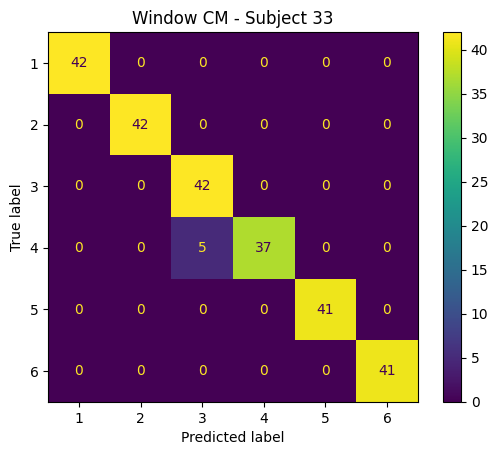


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



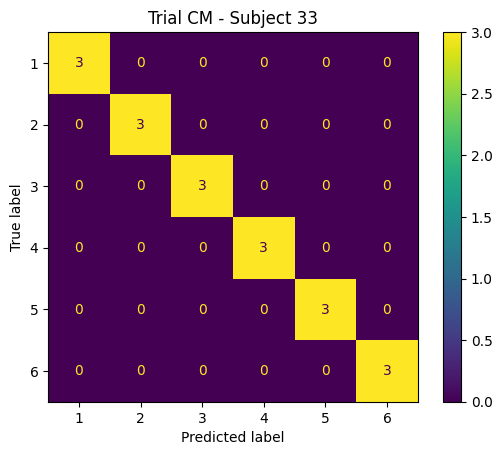


TEST SUBJECT: 34
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_29"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_29      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_29   │ (None, 200, 24)   │          0 │ input_layer_29[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_174 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_175 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_176 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_177 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_2… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_232 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_174[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_234 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_175[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_236 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_176[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_238 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_177[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_232[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_234[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_236[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_238[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_233 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_235 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_237 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_239 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_233[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_235[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_237[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.3481 - loss: 1.7533 - val_accuracy: 0.4612 - val_loss: 1.6648 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 26ms/step - accuracy: 0.5510 - loss: 1.4944 - val_accuracy: 0.6923 - val_loss: 1.1758 - learning_rate: 1.0000e-04
Epoch 3/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.6626 - loss: 1.2321
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6979 - loss: 1.1544 - val_accuracy: 0.7818 - val_loss: 0.8804 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7537 - loss: 0.9704 - val_accuracy: 0.8062 - val_loss: 0.7950 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7742 - loss: 0.8934 - val_accuracy: 0.8062 - val_loss: 0.7364 - learning_rate: 5.0000e-05
Epoch 6/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

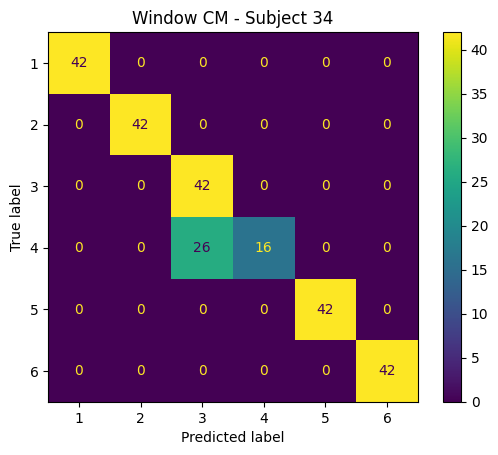


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.60      1.00      0.75         3
           4       1.00      0.33      0.50         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.89        18
   macro avg       0.93      0.89      0.88        18
weighted avg       0.93      0.89      0.88        18



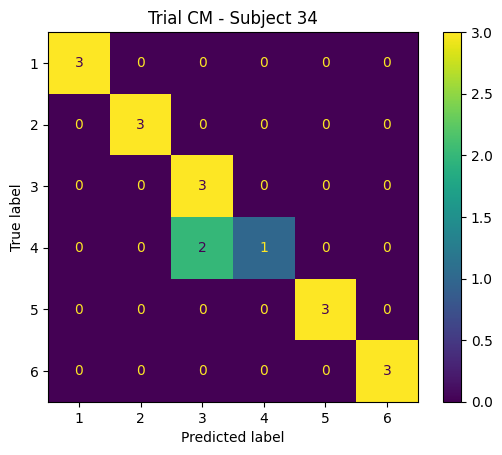


TEST SUBJECT: 35
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_30"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_30      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_30   │ (None, 200, 24)   │          0 │ input_layer_30[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_180 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_181 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_182 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_183 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_240 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_180[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_242 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_181[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_244 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_182[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_246 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_183[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_240[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_242[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_244[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_246[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_241 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_243 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_245 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_247 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_241[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_243[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_245[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3955 - loss: 1.7551 - val_accuracy: 0.6250 - val_loss: 1.6885 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5627 - loss: 1.5093 - val_accuracy: 0.7455 - val_loss: 1.2744 - learning_rate: 1.0000e-04
Epoch 3/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6778 - loss: 1.2415
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6986 - loss: 1.1594 - val_accuracy: 0.7480 - val_loss: 0.9326 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7317 - loss: 0.9610 - val_accuracy: 0.7550 - val_loss: 0.8469 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7494 - loss: 0.8875 - val_accuracy: 0.7545 - val_loss: 0.7984 - learning_rate: 5.0000e-05
Epoch 6/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

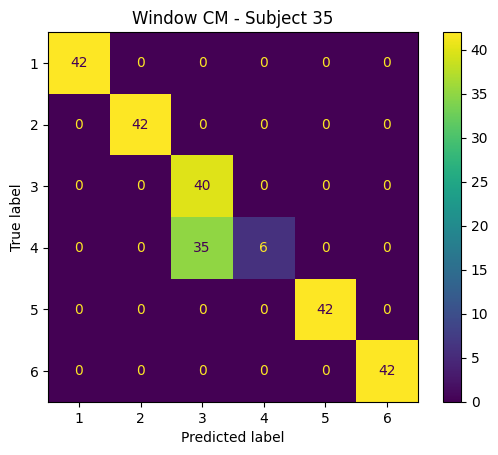


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.50      1.00      0.67         3
           4       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

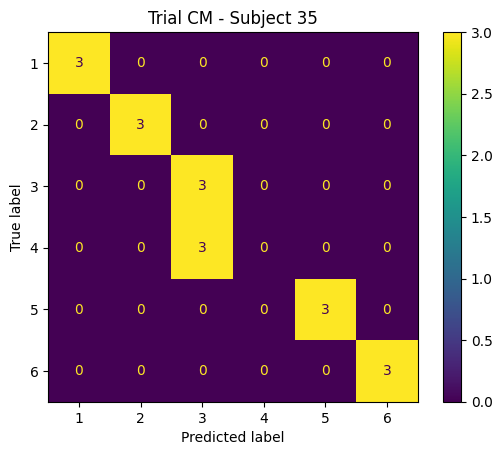


TEST SUBJECT: 36
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_31"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_31      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_31   │ (None, 200, 24)   │          0 │ input_layer_31[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_186 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_187 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_188 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_189 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_248 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_186[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_250 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_187[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_252 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_188[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_254 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_189[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_248[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_250[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_252[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_254[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_249 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_251 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_253 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_255 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_249[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_251[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_253[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.3912 - loss: 1.7560 - val_accuracy: 0.4975 - val_loss: 1.6717 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.5766 - loss: 1.4779 - val_accuracy: 0.5919 - val_loss: 1.1886 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6749 - loss: 1.2051
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7067 - loss: 1.1331 - val_accuracy: 0.8012 - val_loss: 0.8966 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7494 - loss: 0.9394 - val_accuracy: 0.8231 - val_loss: 0.8091 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7537 - loss: 0.8629 - val_accuracy: 0.8206 - val_loss: 0.7610 - learning_rate: 5.0000e-05
Epoch 6/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

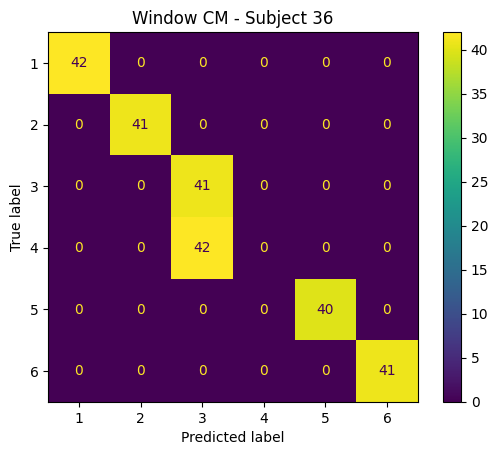


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.50      1.00      0.67         3
           4       0.00      0.00      0.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

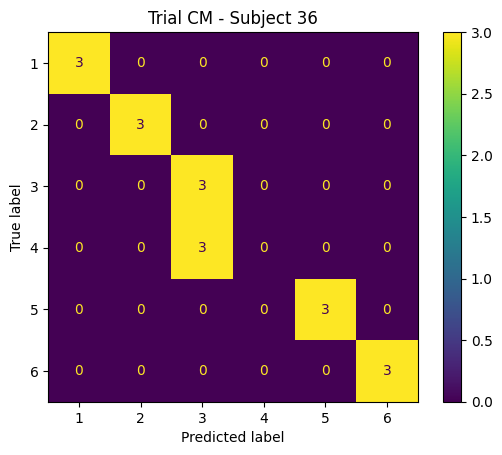


TEST SUBJECT: 37
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_32"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_32      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_32   │ (None, 200, 24)   │          0 │ input_layer_32[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_192 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_193 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_194 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_195 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_256 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_192[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_258 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_193[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_260 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_194[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_262 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_195[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_256[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_258[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_260[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_262[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_257 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_259 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_261 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_263 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_257[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_259[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_261[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4455 - loss: 1.7645 - val_accuracy: 0.7468 - val_loss: 1.7039 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6552 - loss: 1.5215 - val_accuracy: 0.7453 - val_loss: 1.2256 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7011 - loss: 1.2249
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7119 - loss: 1.1460 - val_accuracy: 0.7840 - val_loss: 0.9056 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7518 - loss: 0.9511 - val_accuracy: 0.7860 - val_loss: 0.8214 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7643 - loss: 0.8805 - val_accuracy: 0.8019 - val_loss: 0.7697 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accurac

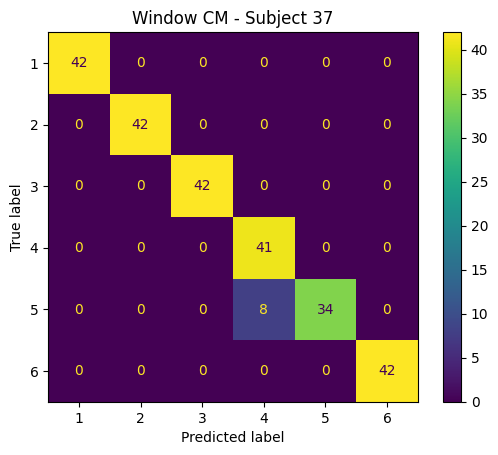


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



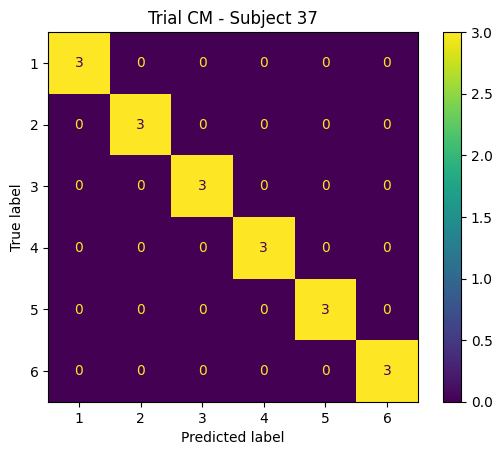


TEST SUBJECT: 38
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_33"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_33      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_33   │ (None, 200, 24)   │          0 │ input_layer_33[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_198 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_199 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_200 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_201 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_264 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_198[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_266 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_199[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_268 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_200[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_270 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_201[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_264[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_266[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_268[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_270[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_265 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_267 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_269 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_271 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_265[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_267[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_269[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.3729 - loss: 1.7710 - val_accuracy: 0.4709 - val_loss: 1.7245 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6123 - loss: 1.5706 - val_accuracy: 0.7877 - val_loss: 1.2513 - learning_rate: 1.0000e-04
Epoch 3/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7101 - loss: 1.2720
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7342 - loss: 1.1787 - val_accuracy: 0.7971 - val_loss: 0.8549 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7778 - loss: 0.9612 - val_accuracy: 0.7961 - val_loss: 0.7421 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7892 - loss: 0.8793 - val_accuracy: 0.8185 - val_loss: 0.6761 - learning_rate: 5.0000e-05
Epoch 6/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

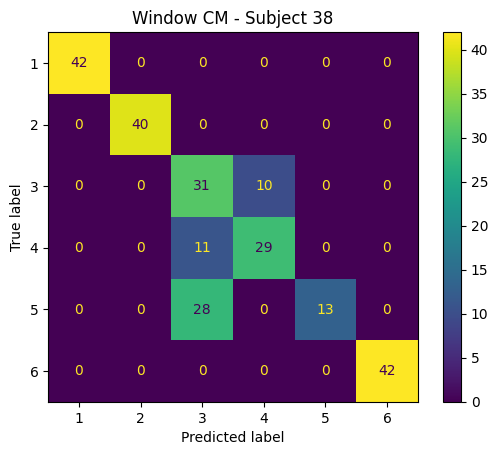


TRIAL ACC: 0.7777777777777778
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.40      0.67      0.50         3
           4       0.67      0.67      0.67         3
           5       1.00      0.33      0.50         3
           6       1.00      1.00      1.00         3

    accuracy                           0.78        18
   macro avg       0.84      0.78      0.78        18
weighted avg       0.84      0.78      0.78        18



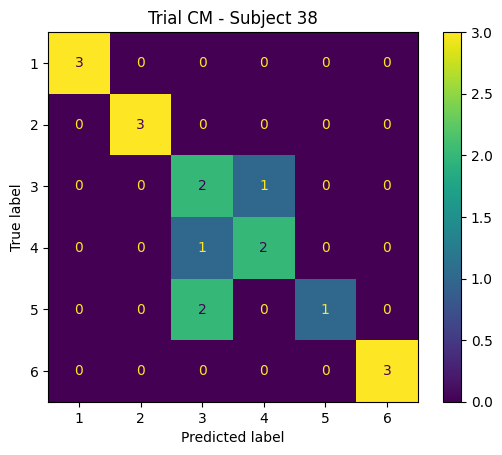


TEST SUBJECT: 39
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_34"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_34      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_34   │ (None, 200, 24)   │          0 │ input_layer_34[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_204 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_205 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_206 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_207 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_272 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_204[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_274 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_205[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_276 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_206[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_278 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_207[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_272[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_274[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_276[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_278[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_273 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_275 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_277 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_279 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_273[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_275[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_277[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 26ms/step - accuracy: 0.4310 - loss: 1.7622 - val_accuracy: 0.6421 - val_loss: 1.6957 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.6295 - loss: 1.5320 - val_accuracy: 0.6142 - val_loss: 1.2030 - learning_rate: 1.0000e-04
Epoch 3/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6662 - loss: 1.2328
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.6955 - loss: 1.1486 - val_accuracy: 0.8273 - val_loss: 0.8917 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7490 - loss: 0.9638 - val_accuracy: 0.8711 - val_loss: 0.8148 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7682 - loss: 0.8886 - val_accuracy: 0.8776 - val_loss: 0.7890 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

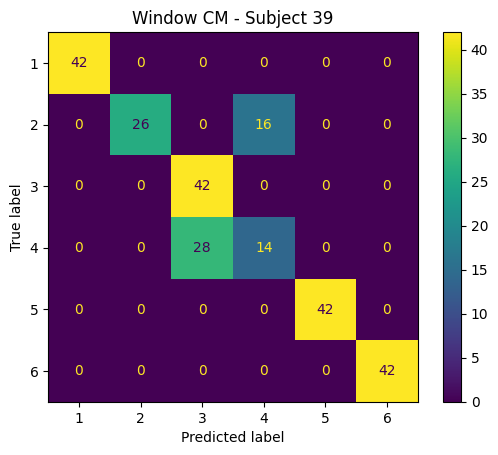


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      0.67      0.80         3
           3       0.60      1.00      0.75         3
           4       0.50      0.33      0.40         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.85      0.83      0.82        18
weighted avg       0.85      0.83      0.83        18



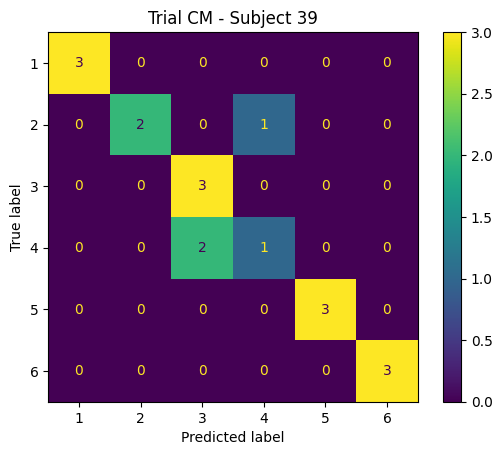


TEST SUBJECT: 40
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_35"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_35      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_35   │ (None, 200, 24)   │          0 │ input_layer_35[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_210 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_211 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_212 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_213 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_280 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_210[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_282 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_211[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_284 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_212[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_286 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_213[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_280[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_282[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_284[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_286[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_281 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_283 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_285 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_287 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_281[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_283[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_285[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 28ms/step - accuracy: 0.4552 - loss: 1.7610 - val_accuracy: 0.7354 - val_loss: 1.7011 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6532 - loss: 1.5213 - val_accuracy: 0.6748 - val_loss: 1.1997 - learning_rate: 1.0000e-04
Epoch 3/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.6891 - loss: 1.2124
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step - accuracy: 0.7071 - loss: 1.1297 - val_accuracy: 0.7835 - val_loss: 0.8582 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7502 - loss: 0.9284 - val_accuracy: 0.7925 - val_loss: 0.7747 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7620 - loss: 0.8559 - val_accuracy: 0.8014 - val_loss: 0.7212 - learning_rate: 5.0000e-05
Epoch 6/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

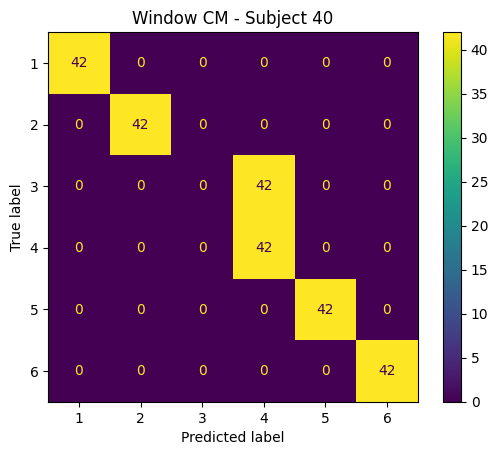


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         3
           4       0.50      1.00      0.67         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

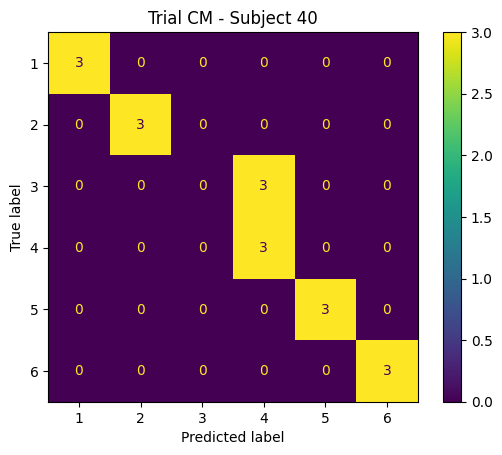


TEST SUBJECT: 41
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_36"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_36      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_36   │ (None, 200, 24)   │          0 │ input_layer_36[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_216 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_217 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_218 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_219 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_288 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_216[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_290 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_217[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_292 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_218[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_294 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_219[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_288[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_290[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_292[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_294[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_289 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_291 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_293 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_295 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_289[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_291[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_293[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 12s 27ms/step - accuracy: 0.4377 - loss: 1.7622 - val_accuracy: 0.7074 - val_loss: 1.7053 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.6462 - loss: 1.5511 - val_accuracy: 0.7203 - val_loss: 1.2075 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.7061 - loss: 1.2463
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.7209 - loss: 1.1564 - val_accuracy: 0.7496 - val_loss: 0.8351 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7549 - loss: 0.9412 - val_accuracy: 0.7670 - val_loss: 0.7552 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 8s 32ms/step - accuracy: 0.7604 - loss: 0.8652 - val_accuracy: 0.7968 - val_loss: 0.7180 - learning_rate: 5.0000e-05
Epoch 6/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accurac

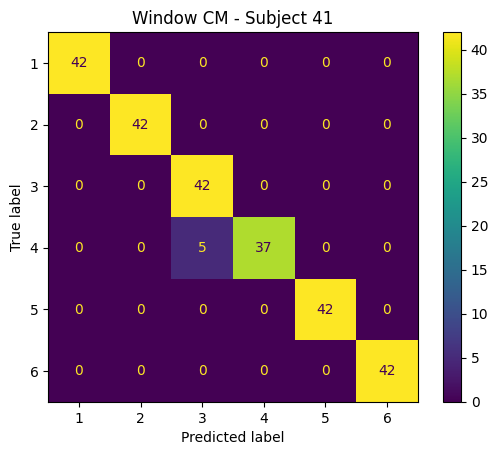


TRIAL ACC: 1.0
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      1.00      1.00         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



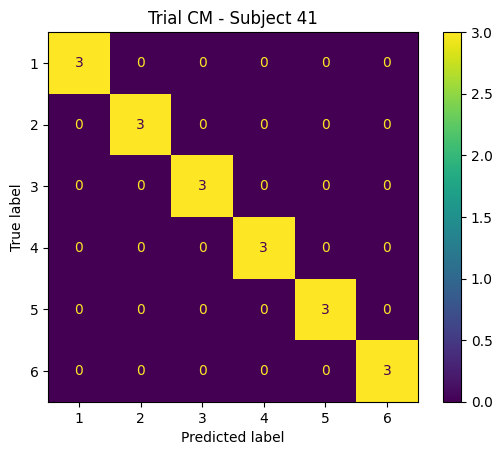


TEST SUBJECT: 42
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_37"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_37      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_37   │ (None, 200, 24)   │          0 │ input_layer_37[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_222 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_223 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_224 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_225 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_296 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_222[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_298 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_223[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_300 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_224[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_302 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_225[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_296[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_298[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_300[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_302[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_297 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_299 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_301 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_303 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_297[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_299[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_301[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 14s 27ms/step - accuracy: 0.3918 - loss: 1.7621 - val_accuracy: 0.6244 - val_loss: 1.7108 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 25ms/step - accuracy: 0.5835 - loss: 1.5277 - val_accuracy: 0.6388 - val_loss: 1.2377 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.6339 - loss: 1.2445
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - accuracy: 0.6573 - loss: 1.1615 - val_accuracy: 0.7511 - val_loss: 0.9207 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7326 - loss: 0.9680 - val_accuracy: 0.7938 - val_loss: 0.8425 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7643 - loss: 0.8914 - val_accuracy: 0.7953 - val_loss: 0.7925 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accurac

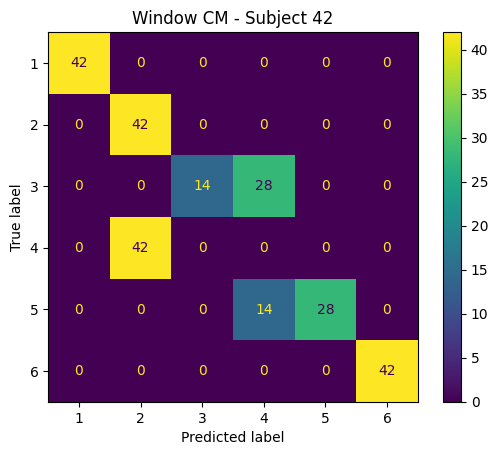


TRIAL ACC: 0.6666666666666666
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       0.50      1.00      0.67         3
           3       1.00      0.33      0.50         3
           4       0.00      0.00      0.00         3
           5       1.00      0.67      0.80         3
           6       1.00      1.00      1.00         3

    accuracy                           0.67        18
   macro avg       0.75      0.67      0.66        18
weighted avg       0.75      0.67      0.66        18



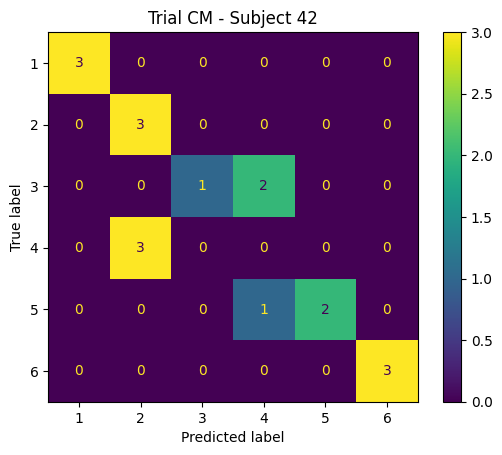


TEST SUBJECT: 43
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_38"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_38      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_38   │ (None, 200, 24)   │          0 │ input_layer_38[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_228 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_229 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_230 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_231 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_304 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_228[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_306 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_229[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_308 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_230[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_310 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_231[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_304[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_306[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_308[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_310[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_305 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_307 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_309 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_311 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_305[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_307[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_309[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 15s 30ms/step - accuracy: 0.3492 - loss: 1.7554 - val_accuracy: 0.6847 - val_loss: 1.6728 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5885 - loss: 1.5270 - val_accuracy: 0.7618 - val_loss: 1.2456 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6749 - loss: 1.2656
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.6946 - loss: 1.1947 - val_accuracy: 0.7907 - val_loss: 0.8769 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7336 - loss: 0.9904 - val_accuracy: 0.8170 - val_loss: 0.7779 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7481 - loss: 0.9103 - val_accuracy: 0.8240 - val_loss: 0.7223 - learning_rate: 5.0000e-05
Epoch 6/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accurac

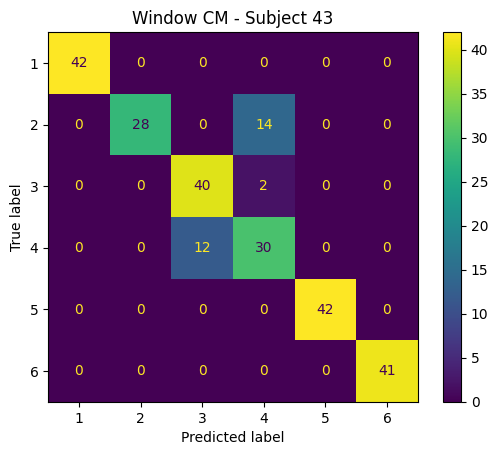


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      0.67      0.80         3
           3       0.75      1.00      0.86         3
           4       0.67      0.67      0.67         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.89        18
   macro avg       0.90      0.89      0.89        18
weighted avg       0.90      0.89      0.89        18



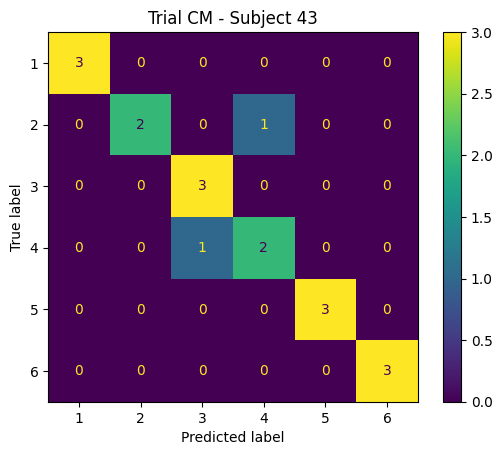


TEST SUBJECT: 44
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_39"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_39      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_39   │ (None, 200, 24)   │          0 │ input_layer_39[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_234 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_235 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_236 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_237 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_3… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_312 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_234[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_314 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_235[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_316 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_236[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_318 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_237[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_312[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_314[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_316[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_318[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_313 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_315 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_317 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_319 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_313[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_315[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_317[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 16s 31ms/step - accuracy: 0.4210 - loss: 1.7600 - val_accuracy: 0.6867 - val_loss: 1.6996 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6306 - loss: 1.5304 - val_accuracy: 0.7454 - val_loss: 1.2486 - learning_rate: 1.0000e-04
Epoch 3/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6970 - loss: 1.2329
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7157 - loss: 1.1372 - val_accuracy: 0.7877 - val_loss: 0.8725 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.7514 - loss: 0.9141 - val_accuracy: 0.8299 - val_loss: 0.7967 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7580 - loss: 0.8454 - val_accuracy: 0.8349 - val_loss: 0.7656 - learning_rate: 5.0000e-05
Epoch 6/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accurac

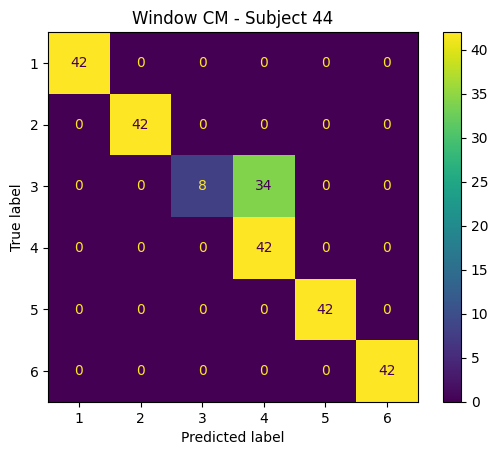


TRIAL ACC: 0.8888888888888888
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       1.00      0.33      0.50         3
           4       0.60      1.00      0.75         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.89        18
   macro avg       0.93      0.89      0.88        18
weighted avg       0.93      0.89      0.88        18



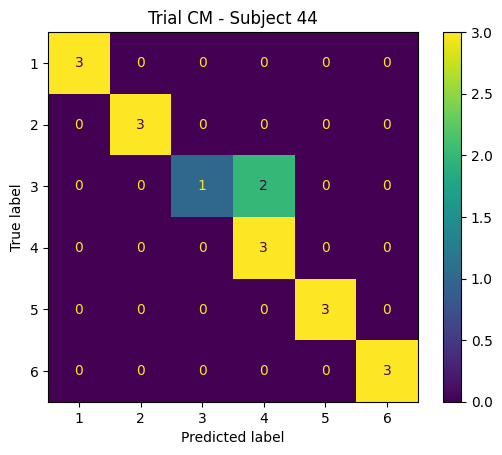


TEST SUBJECT: 45
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_40"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_40      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_40   │ (None, 200, 24)   │          0 │ input_layer_40[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_240 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_241 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_242 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_243 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_320 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_240[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_322 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_241[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_324 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_242[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_326 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_243[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_320[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_322[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_324[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_326[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_321 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_323 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_325 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_327 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_321[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_323[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_325[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 15s 31ms/step - accuracy: 0.4107 - loss: 1.7453 - val_accuracy: 0.6094 - val_loss: 1.6639 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.5796 - loss: 1.4502 - val_accuracy: 0.6602 - val_loss: 1.1306 - learning_rate: 1.0000e-04
Epoch 3/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.6265 - loss: 1.1680
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.6451 - loss: 1.1049 - val_accuracy: 0.7628 - val_loss: 0.8330 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step - accuracy: 0.7048 - loss: 0.9576 - val_accuracy: 0.8361 - val_loss: 0.7667 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.7244 - loss: 0.9117 - val_accuracy: 0.8435 - val_loss: 0.7252 - learning_rate: 5.0000e-05
Epoch 6/60
258/259 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - accurac

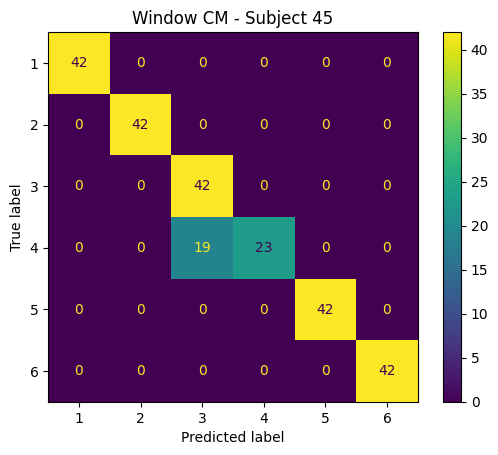


TRIAL ACC: 0.9444444444444444
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.75      1.00      0.86         3
           4       1.00      0.67      0.80         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.94        18
   macro avg       0.96      0.94      0.94        18
weighted avg       0.96      0.94      0.94        18



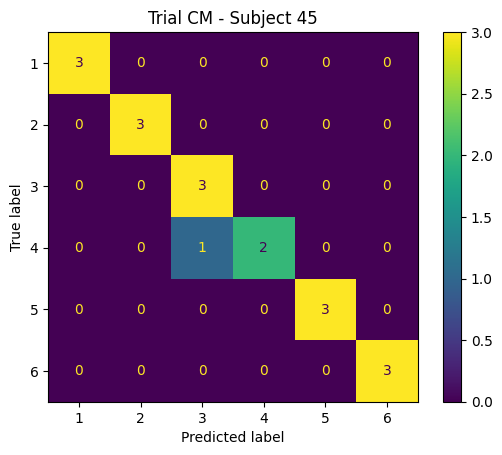


TEST SUBJECT: 46
Model input: (200, 24)
Sensor feature size: 6


Model: "functional_41"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_41      │ (None, 200, 24)   │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ sensor_dropout_41   │ (None, 200, 24)   │          0 │ input_layer_41[0… │
│ (SensorDropout)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_246 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_247 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_248 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_249 (Lambda) │ (None, 200, 6)    │          0 │ sensor_dropout_4… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_328 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_246[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_330 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_247[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_332 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_248[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_334 (Conv1D) │ (None, 200, 32)   │        992 │ lambda_249[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_328[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_330[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_332[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_334[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_329 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_331 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_333 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_335 (Conv1D) │ (None, 200, 32)   │      3,104 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_329[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_331[0][0]  │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 200, 32)   │        128 │ conv1d_333[0][0]

 Total params: 34,535 (134.90 KB)

 Trainable params: 34,023 (132.90 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.4315 - loss: 1.7484 - val_accuracy: 0.5581 - val_loss: 1.6570 - learning_rate: 1.0000e-04
Epoch 2/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5850 - loss: 1.4492 - val_accuracy: 0.6043 - val_loss: 1.1588 - learning_rate: 1.0000e-04
Epoch 3/60
257/259 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.6684 - loss: 1.1510
Epoch 3: ReduceLROnPlateau reducing learning rate to 4.999999873689376e-05.
259/259 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.6961 - loss: 1.0770 - val_accuracy: 0.7085 - val_loss: 0.8846 - learning_rate: 1.0000e-04
Epoch 4/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7479 - loss: 0.9008 - val_accuracy: 0.7408 - val_loss: 0.8110 - learning_rate: 5.0000e-05
Epoch 5/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.7621 - loss: 0.8363 - val_accuracy: 0.7537 - val_loss: 0.7696 - learning_rate: 5.0000e-05
Epoch 6/60
259/259 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accurac

C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

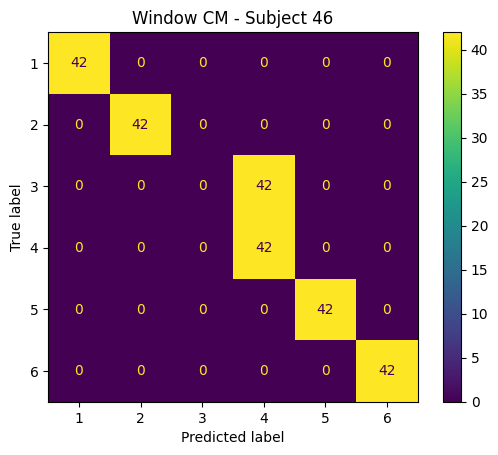


TRIAL ACC: 0.8333333333333334
              precision    recall  f1-score   support

           1       1.00      1.00      1.00         3
           2       1.00      1.00      1.00         3
           3       0.00      0.00      0.00         3
           4       0.50      1.00      0.67         3
           5       1.00      1.00      1.00         3
           6       1.00      1.00      1.00         3

    accuracy                           0.83        18
   macro avg       0.75      0.83      0.78        18
weighted avg       0.75      0.83      0.78        18



C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:1531: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\HP\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\sklearn\metrics\_classification.py:153

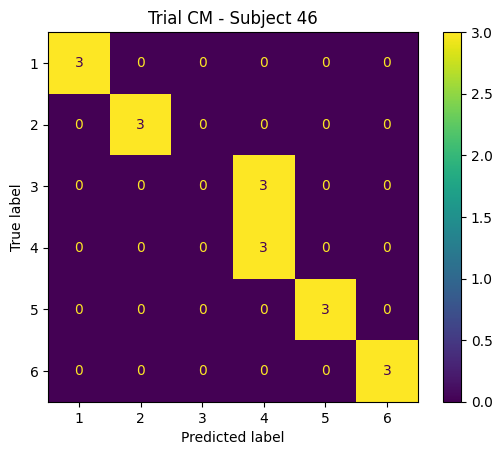

In [12]:
# CELL 12 — LOSO Loop (Per-Fold Only)
from collections import defaultdict
import gc

EXCLUDED_SUBJECTS = [16, 21, 26, 29]

subjects = sorted(
    s for s in np.unique(subj_all)
    if s not in EXCLUDED_SUBJECTS
)

window_scores = []
trial_scores = []

all_window_true = []
all_window_pred = []

all_trial_true = []
all_trial_pred = []
all_trial_subjects = []

# ✅ store probs + attention inputs
all_window_probs = []
all_attention_inputs = []   # 🔥 NEW

fold_results = []

for test_subject in subjects:

    print("\n============================")
    print("TEST SUBJECT:", test_subject)
    print("============================")

    # -----------------------
    # SPLIT
    # -----------------------
    train_subjects = [s for s in subjects if s != test_subject]

    val_size = max(1, int(0.2 * len(train_subjects)))
    val_subjects = np.random.choice(train_subjects, size=val_size, replace=False)

    train_subjects_final = [s for s in train_subjects if s not in val_subjects]

    train_mask = np.isin(subj_all, train_subjects_final)
    val_mask   = np.isin(subj_all, val_subjects)
    test_mask  = subj_all == test_subject

    X_train = X_all[train_mask]
    y_train = y_all[train_mask]

    X_val   = X_all[val_mask]
    y_val   = y_all[val_mask]

    X_test  = X_all[test_mask]
    y_test  = y_all[test_mask]

    trial_test = trial_all[test_mask]
    subject_test = subj_all[test_mask]

    # -----------------------
    # NORMALIZATION
    # -----------------------
    means, stds = compute_sensor_norm(X_train)

    X_train = apply_sensor_norm(X_train, means, stds)
    X_val   = apply_sensor_norm(X_val, means, stds)
    X_test  = apply_sensor_norm(X_test, means, stds)

    # store normalized test for attention
    all_attention_inputs.append(X_test)

    # -----------------------
    # ONE HOT
    # -----------------------
    y_train_cat = keras.utils.to_categorical(y_train, len(POSTURES))
    y_val_cat   = keras.utils.to_categorical(y_val, len(POSTURES))

    # -----------------------
    # MODEL
    # -----------------------
    model = build_model(X_train.shape[1:])

    early = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True
    )

    hist = model.fit(
        X_train,
        y_train_cat,
        validation_data=(X_val, y_val_cat),
        epochs=60,
        batch_size=32,
        callbacks=[early, lr_scheduler],
        verbose=1
    )

    # -----------------------
    # WINDOW LEVEL
    # -----------------------
    probs = model.predict(X_test, verbose=0)

    y_pred = np.argmax(probs, axis=1)
    y_true = y_test

    all_window_probs.append(probs)

    window_acc = np.mean(y_pred == y_true)
    window_scores.append(window_acc)

    print("\nWINDOW ACC:", window_acc)
    print(classification_report(y_true, y_pred, target_names=POSTURES))

    cm = confusion_matrix(y_true, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()
    plt.title(f"Window CM - Subject {test_subject}")
    plt.show()

    all_window_true.extend(y_true)
    all_window_pred.extend(y_pred)

    # -----------------------
    # TRIAL LEVEL
    # -----------------------
    trial_probs = defaultdict(list)
    trial_true = {}

    for p,true,s,t in zip(probs, y_true, subject_test, trial_test):
        key = (s,t)
        trial_probs[key].append(p)
        trial_true[key] = true

    trial_pred = []
    trial_true_list = []
    trial_subjects = []

    for k in trial_probs:
        w = np.array(trial_probs[k])
        summed = np.sum(np.log(w + 1e-8), axis=0)
        pred = np.argmax(summed)

        trial_pred.append(pred)
        trial_true_list.append(trial_true[k])
        trial_subjects.append(k[0])

    trial_pred = np.array(trial_pred)
    trial_true_list = np.array(trial_true_list)
    trial_subjects = np.array(trial_subjects)

    trial_acc = np.mean(trial_pred == trial_true_list)
    trial_scores.append(trial_acc)

    print("\nTRIAL ACC:", trial_acc)
    print(classification_report(trial_true_list, trial_pred, target_names=POSTURES))

    cm = confusion_matrix(trial_true_list, trial_pred)
    ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()
    plt.title(f"Trial CM - Subject {test_subject}")
    plt.show()

    all_trial_true.extend(trial_true_list)
    all_trial_pred.extend(trial_pred)
    all_trial_subjects.extend(trial_subjects)

    # SAVE FINAL MODEL
    if test_subject == subjects[-1]:
        final_model = model
        final_means = means
        final_stds = stds

    del model, hist
    gc.collect()

In [13]:
# CELL 13 — Save Final Model + Weights + Norm Stats
final_weights_path = "loso_final_new.weights.h5"
final_model_path = "loso_final_model_new.keras"
final_norm_path = "loso_norm_stats_new.npz"

# Save weights (recommended for reload with rebuild)
final_model.save_weights(final_weights_path)
print("Saved final weights to:", final_weights_path)

# Save full model (may require rebuild+weights for reload if Lambda issues)
final_model.save(final_model_path)
print("Saved full model to:", final_model_path)

# Save normalization stats
np.savez(
    final_norm_path,
    **{f"mean_{i}": m for i, m in enumerate(final_means)},
    **{f"std_{i}": s for i, s in enumerate(final_stds)}
 )
print("Saved normalization stats to:", final_norm_path)

Saved final weights to: loso_final_new.weights.h5
Saved full model to: loso_final_model_new.keras
Saved normalization stats to: loso_norm_stats_new.npz



===== FINAL LOSO RESULTS =====
Avg Window Acc: 0.8265382271920565
Avg Trial Acc: 0.8306878306878308
Probs shape: (10544, 6)
True shape: (10544,)

WINDOW METRICS
              precision    recall  f1-score   support

           1       0.98      0.99      0.98      1762
           2       0.93      0.94      0.93      1747
           3       0.63      0.60      0.62      1759
           4       0.63      0.61      0.62      1756
           5       0.84      0.89      0.86      1760
           6       0.95      0.92      0.93      1760

    accuracy                           0.83     10544
   macro avg       0.82      0.83      0.83     10544
weighted avg       0.82      0.83      0.83     10544



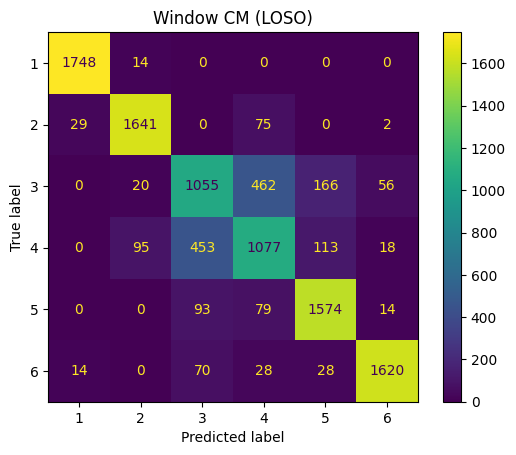


TRIAL METRICS
              precision    recall  f1-score   support

           1       0.97      0.99      0.98       126
           2       0.93      0.94      0.93       126
           3       0.64      0.61      0.63       126
           4       0.64      0.63      0.63       126
           5       0.84      0.90      0.87       126
           6       0.95      0.92      0.94       126

    accuracy                           0.83       756
   macro avg       0.83      0.83      0.83       756
weighted avg       0.83      0.83      0.83       756



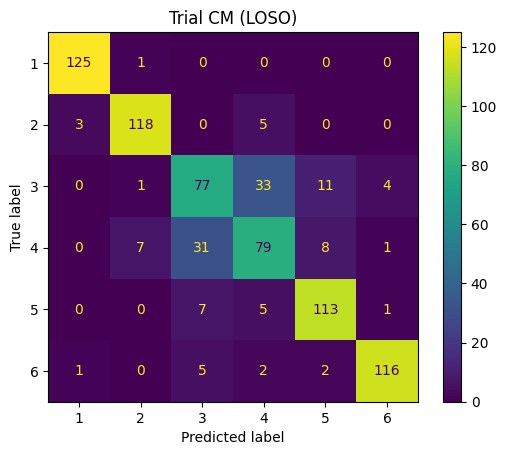


===== SUBJECT RESULTS =====
Avg Subject Acc: 0.8452380952380952

SUBJECT METRICS
              precision    recall  f1-score   support

           1       1.00      1.00      1.00        42
           2       0.95      0.98      0.96        42
           3       0.65      0.62      0.63        42
           4       0.63      0.62      0.63        42
           5       0.84      0.90      0.87        42
           6       0.98      0.95      0.96        42

    accuracy                           0.85       252
   macro avg       0.84      0.85      0.84       252
weighted avg       0.84      0.85      0.84       252



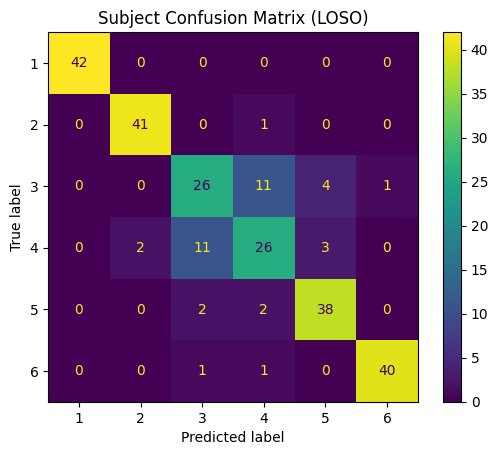

In [14]:
# CELL 13 — Final Results (All Folds)
print("\n===== FINAL LOSO RESULTS =====")

print("Avg Window Acc:", np.mean(window_scores))
print("Avg Trial Acc:", np.mean(trial_scores))

# =========================================
# FIX PROB SHAPE
# =========================================
all_window_probs = np.concatenate(all_window_probs, axis=0)

print("Probs shape:", all_window_probs.shape)
print("True shape:", np.array(all_window_true).shape)

# -----------------------
# WINDOW METRICS
# -----------------------
print("\nWINDOW METRICS")
print(classification_report(all_window_true, all_window_pred, target_names=POSTURES))

cm = confusion_matrix(all_window_true, all_window_pred)
ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()
plt.title("Window CM (LOSO)")
plt.show()

# -----------------------
# TRIAL METRICS
# -----------------------
print("\nTRIAL METRICS")
print(classification_report(all_trial_true, all_trial_pred, target_names=POSTURES))

cm = confusion_matrix(all_trial_true, all_trial_pred)
ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()
plt.title("Trial CM (LOSO)")
plt.show()

# =========================================
# SUBJECT LEVEL (VOTING)
# =========================================

subject_votes = defaultdict(list)
subject_true = {}

for pred, true, s in zip(all_trial_pred, all_trial_true, all_trial_subjects):
    key = (s, true)
    subject_votes[key].append(pred)
    subject_true[key] = true

all_subject_pred = []
all_subject_true = []

for k in subject_votes:
    votes = np.array(subject_votes[k])
    pred = np.bincount(votes).argmax()

    all_subject_pred.append(pred)
    all_subject_true.append(subject_true[k])

all_subject_pred = np.array(all_subject_pred)
all_subject_true = np.array(all_subject_true)

print("\n===== SUBJECT RESULTS =====")
print("Avg Subject Acc:", np.mean(all_subject_pred == all_subject_true))

# -----------------------
# SUBJECT METRICS
# -----------------------
print("\nSUBJECT METRICS")
print(classification_report(
    all_subject_true,
    all_subject_pred,
    labels=np.arange(len(POSTURES)),
    target_names=POSTURES,
    zero_division=0
))

# -----------------------
# SUBJECT CONFUSION MATRIX
# -----------------------
cm = confusion_matrix(
    all_subject_true,
    all_subject_pred,
    labels=np.arange(len(POSTURES))
)

ConfusionMatrixDisplay(cm, display_labels=POSTURES).plot()
plt.title("Subject Confusion Matrix (LOSO)")
plt.show()

In [15]:
# CELL 14 — Real Deployment Latency
sample = X_all[0:1]
sample = apply_sensor_norm(sample, final_means, final_stds)

for _ in range(10):
    final_model.predict(sample, verbose=0)

latencies = []
N = 100

for _ in range(N):
    start = time.perf_counter()
    final_model.predict(sample, verbose=0)
    end = time.perf_counter()
    latencies.append(end - start)

latencies = np.array(latencies)

print("\n===== LATENCY =====")
print(f"Mean: {latencies.mean()*1000:.3f} ms")
print(f"Std: {latencies.std()*1000:.3f} ms")


===== LATENCY =====
Mean: 94.302 ms
Std: 12.919 ms


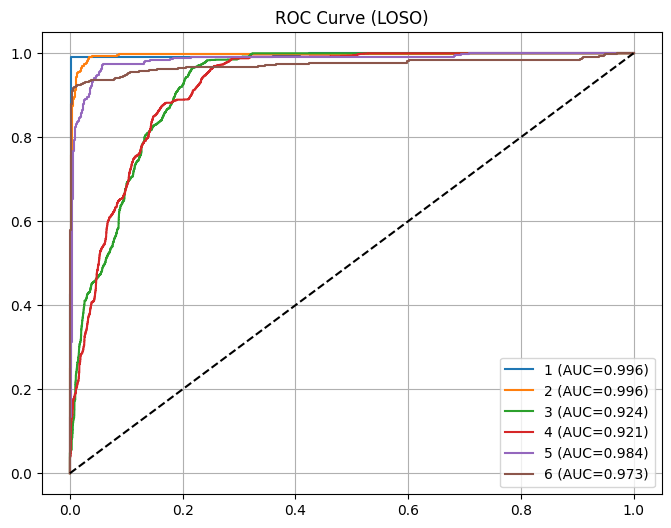


===== ROC AUC SCORES =====
1: 0.9959
2: 0.9960
3: 0.9235
4: 0.9210
5: 0.9842
6: 0.9726


In [16]:
# CELL 15 — ROC Curve
y_true_bin = label_binarize(all_window_true, classes=np.arange(len(POSTURES)))

plt.figure(figsize=(8,6))

for i in range(len(POSTURES)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_window_probs[:, i])
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{POSTURES[i]} (AUC={roc_auc:.3f})")

plt.plot([0,1],[0,1],'k--')
plt.title("ROC Curve (LOSO)")
plt.legend()
plt.grid()
plt.show()

print("\n===== ROC AUC SCORES =====")
for i in range(len(POSTURES)):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_window_probs[:, i])
    print(f"{POSTURES[i]}: {auc(fpr, tpr):.4f}")

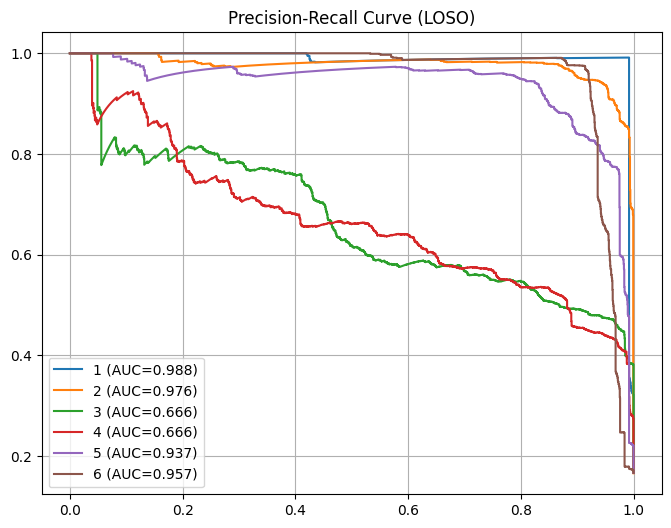

In [17]:
# CELL 16 — PR Curve
plt.figure(figsize=(8,6))

for i in range(len(POSTURES)):
    precision, recall, _ = precision_recall_curve(
        y_true_bin[:, i],
        all_window_probs[:, i]
    )

    pr_auc = auc(recall, precision)

    plt.plot(recall, precision, label=f"{POSTURES[i]} (AUC={pr_auc:.3f})")

plt.title("Precision-Recall Curve (LOSO)")
plt.legend()
plt.grid()
plt.show()